# Results of IMD grid fits

In [1]:
import os
import polars as pl
import numpy as np

from scipy.optimize import minimize
import statsmodels.api as sm  # for linear regression

import matplotlib.pyplot as plt

In [3]:
df_admissions_lines_very_many = pl.read_csv(os.path.join('outputs', 'line_fits_grid_ageonly_to_admissions_imd5_bounds.csv'))

In [4]:
df_admissions_lines_very_many.head()

start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,0.8,1.0,0.0001,0.0007,0.0007,0.0007,0.007,-1.758813,0.0004,0.001,0.001,0.001,0.01,0.1081506
0,0.6,0.8,0.0001,0.0007,0.0007,0.0007,0.007,-2.245089,0.0004,0.001,0.001,0.001,0.01,-0.184314
0,0.4,0.6,0.0001,0.0007,0.0007,0.0007,0.007,-2.238987,0.0004,0.001,0.001,0.001,0.01,-0.286964
0,0.2,0.4,0.0001,0.0007,0.0007,0.0007,0.007,-2.900872,0.0004,0.001,0.0004,0.001,0.01,-0.809578
0,0.0,0.2,0.0001,0.0007,0.0007,0.0007,0.007,-4.019878,0.0004,0.001,0.0004,0.0004,0.01,-1.616865


In [5]:
quantile_min_list = sorted(df_admissions_lines_very_many['depriv_quantile_min'].unique())

quantile_min_list

[0.0, 0.2, 0.4, 0.6, 0.8]

For each quantile, of top X fits, what is the mean and std of the optimised coefficients?

In [6]:
cols_coeffs = [c for c in df_admissions_lines_very_many.columns if (('coeff' in c) & ('start' not in c))]

cols_coeffs

['coeff_age_less65',
 'coeff_age_65',
 'coeff_age_70',
 'coeff_age_75',
 'coeff_age_over80']

coeff_age_less65 7e-05 0.001


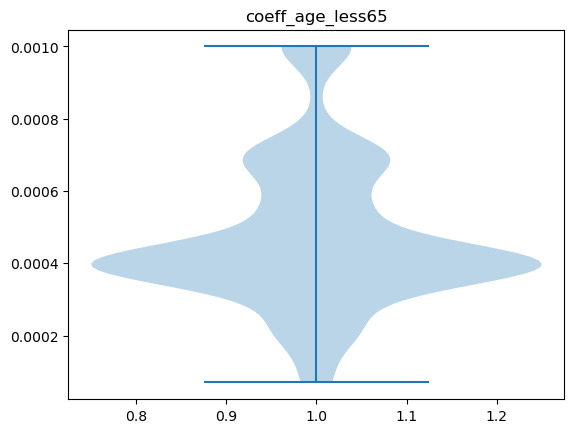

coeff_age_65 0.0004 0.007


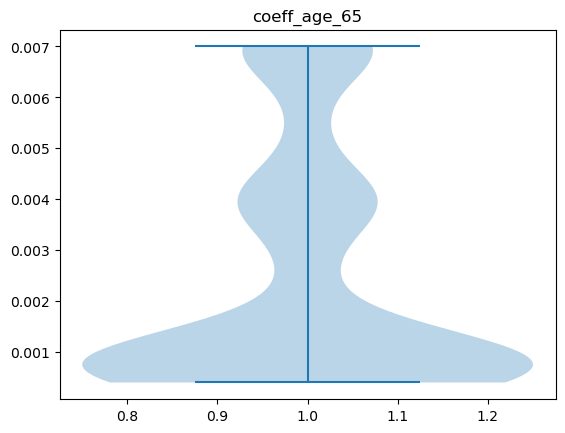

coeff_age_70 0.0004 0.007


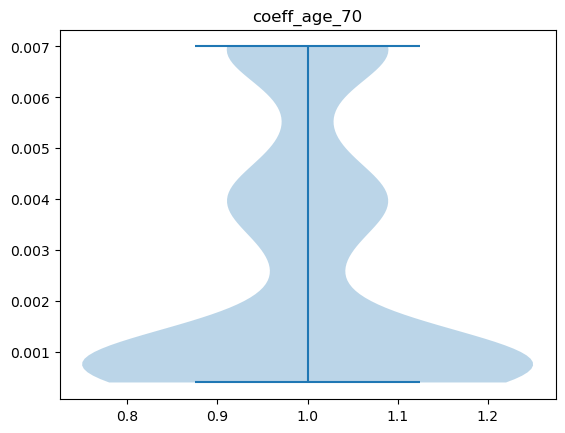

coeff_age_75 0.0004 0.007


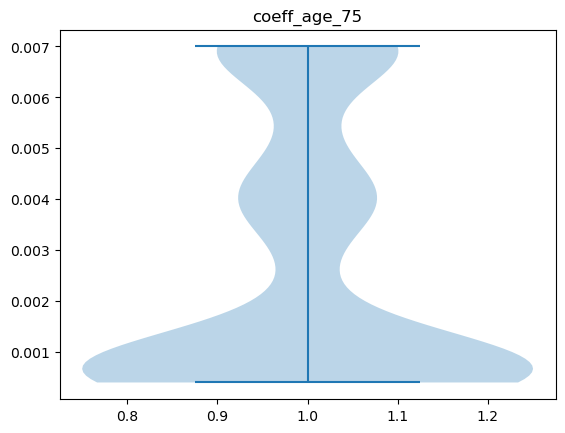

coeff_age_over80 0.0092211 0.02


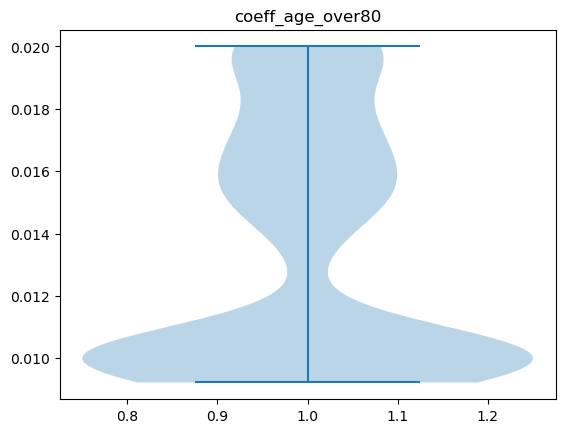

In [42]:
for col in cols_coeffs:
    print(
        col,
        df_admissions_lines_very_many[col].min(),
        df_admissions_lines_very_many[col].max()
    )
    plt.violinplot(df_admissions_lines_very_many[col])
    plt.title(col)
    plt.show()

In [43]:
start_coeff_cols = [c for c in df_admissions_lines_very_many.columns if 'start_coeff' in c]

coeff_start_values = sorted(list(set(df_admissions_lines_very_many[start_coeff_cols].to_numpy().flatten())))

coeff_start_values

[0.0001, 0.0004, 0.0007, 0.001, 0.004, 0.007, 0.01]

In [44]:
len(df_admissions_lines_very_many)

810

In [45]:
mask_start_coeffs = (
    df_admissions_lines_very_many['start_coeff_age_less65'].is_in([0.0001, 0.0004, 0.0007]) &
    df_admissions_lines_very_many['start_coeff_age_65'].is_in([0.0007, 0.001, 0.004]) &
    df_admissions_lines_very_many['start_coeff_age_70'].is_in([0.0007, 0.001, 0.004]) &
    df_admissions_lines_very_many['start_coeff_age_75'].is_in([0.0007, 0.001, 0.004]) &
    df_admissions_lines_very_many['start_coeff_age_over80'].is_in([0.007, 0.01])
)

df_admissions_lines_very_many = df_admissions_lines_very_many.filter(mask_start_coeffs)

In [46]:
len(df_admissions_lines_very_many)

810

Remove fits where any coefficient is exactly a boundary:

In [47]:
bounds_dict = {
    '0.0001': {'min': 7e-05, 'max': 0.0004},
    '0.0004': {'min': 0.0001, 'max': 0.0007},
    '0.0007': {'min': 0.0004, 'max': 0.001},
    '0.001': {'min': 0.0007, 'max': 0.004},
    '0.004': {'min': 0.001, 'max': 0.007},
    '0.007': {'min': 0.004, 'max': 0.01},
    '0.01': {'min': 0.009, 'max': 0.02}
}

bounds_list = []
for k, v in bounds_dict.items():
    for k2, v2 in v.items():
        if v2 in bounds_list:
            pass
        else:
            bounds_list.append(v2)

bounds_list

[7e-05, 0.0004, 0.0001, 0.0007, 0.001, 0.004, 0.007, 0.01, 0.009, 0.02]

In [48]:
mask_bounds = [
    df_admissions_lines_very_many[c].is_in(bounds_list) for c in cols_coeffs
    ]

mask_zero = mask_bounds[0]
for mask in mask_bounds[1:]:
    mask_zero = mask_zero | mask

In [49]:
df_admissions_lines_very_many['start_option'].filter(mask_zero)

start_option
i64
0
0
0
0
0
…
160
160
161


In [55]:
df_admissions_lines_very_many['start_option'].filter(mask_zero) == 0

start_option
bool
true
true
true
true
true
…
false
false
false


In [59]:
df_admissions_lines_very_many['start_option'].unique()

start_option
i64
0
1
2
3
4
…
157
158
159


Only keep options where the bounds are not hit for any IMD band:

In [61]:
start_options_to_keep = []

df_masked_start_options = df_admissions_lines_very_many['start_option'].filter(mask_zero)

for s in df_admissions_lines_very_many['start_option'].unique():
    n_here = len(df_masked_start_options.filter(df_masked_start_options == int(s)))
    if n_here == 0:
        start_options_to_keep.append(s)

start_options_to_keep

[101, 107]

In [63]:
df_admissions_lines_very_many = df_admissions_lines_very_many.filter(df_admissions_lines_very_many['start_option'].is_in(start_options_to_keep))

In [64]:
len(df_admissions_lines_very_many)

10

Round optimised coefficients to some significant figures:

In [65]:
df_admissions_lines_very_many.head()

start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
101,0.8,1.0,0.0004,0.004,0.001,0.004,0.01,0.578216,0.0001923,0.0029385,0.0014156,0.0023728,0.0152694,0.6270606
101,0.6,0.8,0.0004,0.004,0.001,0.004,0.01,0.473958,0.0003445,0.0010086,0.0008206,0.0062429,0.0149735,0.6126032
101,0.4,0.6,0.0004,0.004,0.001,0.004,0.01,0.396751,0.0003682,0.0033449,0.0007661,0.0026057,0.0170094,0.6438448
101,0.2,0.4,0.0004,0.004,0.001,0.004,0.01,0.082708,0.0004923,0.0052209,0.0010103,0.0029514,0.0159668,0.5820854
101,0.0,0.2,0.0004,0.004,0.001,0.004,0.01,-0.509055,0.0005494,0.0069225,0.0039841,0.0010117,0.0160872,0.4962223


Find highest combined R2:

In [66]:
start_options = df_admissions_lines_very_many['start_option'].unique()

In [67]:
dict_r2_combo = {}

for start_option in start_options:
    df_here = df_admissions_lines_very_many.filter(df_admissions_lines_very_many['start_option'] == start_option)
    r2_sum = df_here['rsquared'].sum()
    dict_r2_combo[str(start_option)] = r2_sum

In [68]:
df_r2_combo = pl.from_dict(dict_r2_combo).transpose(include_header=True)

In [69]:
df_r2_combo = df_r2_combo.rename({'column': 'start_option', 'column_0': 'r2_combo'})

In [70]:
df_r2_combo = df_r2_combo.sort('r2_combo', descending=True)

df_r2_combo

start_option,r2_combo
str,f64
"""101""",2.961816
"""107""",2.9570036


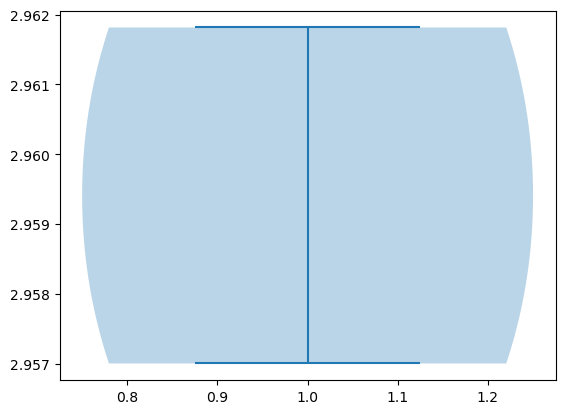

In [71]:
plt.violinplot(df_r2_combo['r2_combo'])
plt.show()

In [72]:
for start_option in df_r2_combo['start_option'][:10]:
    print(start_option)
    display(df_admissions_lines_very_many.filter(df_admissions_lines_very_many['start_option'] == start_option))

101


start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
101,0.8,1.0,0.0004,0.004,0.001,0.004,0.01,0.578216,0.0001923,0.0029385,0.0014156,0.0023728,0.0152694,0.6270606
101,0.6,0.8,0.0004,0.004,0.001,0.004,0.01,0.473958,0.0003445,0.0010086,0.0008206,0.0062429,0.0149735,0.6126032
101,0.4,0.6,0.0004,0.004,0.001,0.004,0.01,0.396751,0.0003682,0.0033449,0.0007661,0.0026057,0.0170094,0.6438448
101,0.2,0.4,0.0004,0.004,0.001,0.004,0.01,0.082708,0.0004923,0.0052209,0.0010103,0.0029514,0.0159668,0.5820854
101,0.0,0.2,0.0004,0.004,0.001,0.004,0.01,-0.509055,0.0005494,0.0069225,0.0039841,0.0010117,0.0160872,0.4962223


107


start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
107,0.8,1.0,0.0004,0.004,0.004,0.004,0.01,0.583549,0.0002254,0.0010754,0.0018612,0.0033977,0.0153865,0.6267682
107,0.6,0.8,0.0004,0.004,0.004,0.004,0.01,0.598182,0.0003472,0.0010037,0.0011469,0.0054938,0.0151559,0.6128349
107,0.4,0.6,0.0004,0.004,0.004,0.004,0.01,0.588812,0.0003796,0.002293,0.0010112,0.0051112,0.0158399,0.6436897
107,0.2,0.4,0.0004,0.004,0.004,0.004,0.01,0.367263,0.0004755,0.0040768,0.0030759,0.0034858,0.0147164,0.5797903
107,0.0,0.2,0.0004,0.004,0.004,0.004,0.01,-0.130848,0.0005436,0.0057224,0.0042974,0.0040165,0.0150141,0.4939205


Repeat with coeffs rounded:

In [80]:
for start_option in df_r2_combo['start_option'][:10]:
    print(start_option)
    df_here = df_admissions_lines_very_many.filter(df_admissions_lines_very_many['start_option'] == start_option)
    for col in cols_coeffs:
        df_here = df_here.with_columns(df_here[col].round_sig_figs(1))
    display(df_here)

101


start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
101,0.8,1.0,0.0004,0.004,0.001,0.004,0.01,0.578216,0.0002,0.003,0.001,0.002,0.02,0.6270606
101,0.6,0.8,0.0004,0.004,0.001,0.004,0.01,0.473958,0.0003,0.001,0.0008,0.006,0.01,0.6126032
101,0.4,0.6,0.0004,0.004,0.001,0.004,0.01,0.396751,0.0004,0.003,0.0008,0.003,0.02,0.6438448
101,0.2,0.4,0.0004,0.004,0.001,0.004,0.01,0.082708,0.0005,0.005,0.001,0.003,0.02,0.5820854
101,0.0,0.2,0.0004,0.004,0.001,0.004,0.01,-0.509055,0.0005,0.007,0.004,0.001,0.02,0.4962223


107


start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
107,0.8,1.0,0.0004,0.004,0.004,0.004,0.01,0.583549,0.0002,0.001,0.002,0.003,0.02,0.6267682
107,0.6,0.8,0.0004,0.004,0.004,0.004,0.01,0.598182,0.0003,0.001,0.001,0.005,0.02,0.6128349
107,0.4,0.6,0.0004,0.004,0.004,0.004,0.01,0.588812,0.0004,0.002,0.001,0.005,0.02,0.6436897
107,0.2,0.4,0.0004,0.004,0.004,0.004,0.01,0.367263,0.0005,0.004,0.003,0.003,0.01,0.5797903
107,0.0,0.2,0.0004,0.004,0.004,0.004,0.01,-0.130848,0.0005,0.006,0.004,0.004,0.02,0.4939205


Run grid:

Calculating:

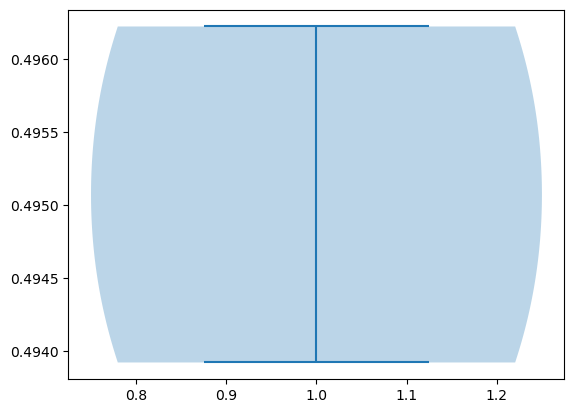

0.0005436 0.0005494 0.0005465
0.0057224 0.0069225 0.00632245
0.0039841 0.0042974 0.00414075
0.0010117 0.0040165 0.0025141
0.0150141 0.0160872 0.01555065


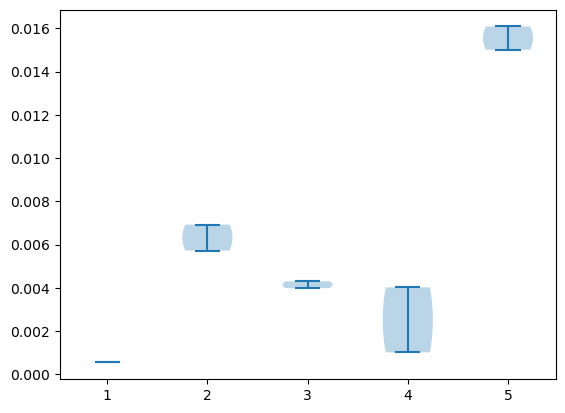

0.0 0.4962223 0.4939205 0.44660007
2 2


start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
101,0.0,0.2,0.0004,0.004,0.001,0.004,0.01,-0.509055,0.0005494,0.0069225,0.0039841,0.0010117,0.0160872,0.4962223
107,0.0,0.2,0.0004,0.004,0.004,0.004,0.01,-0.130848,0.0005436,0.0057224,0.0042974,0.0040165,0.0150141,0.4939205


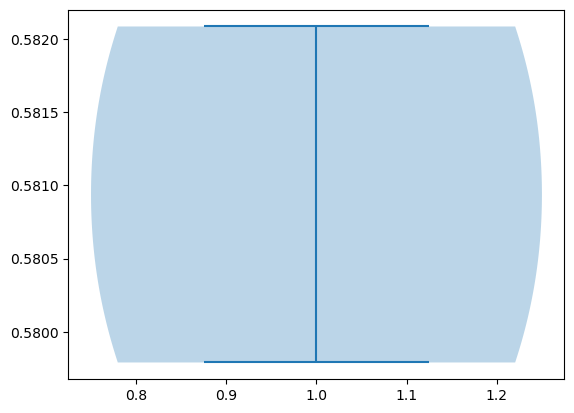

0.0004755 0.0004923 0.0004839
0.0040768 0.0052209 0.0046488499999999995
0.0010103 0.0030759 0.0020431
0.0029514 0.0034858 0.0032186
0.0147164 0.0159668 0.0153416


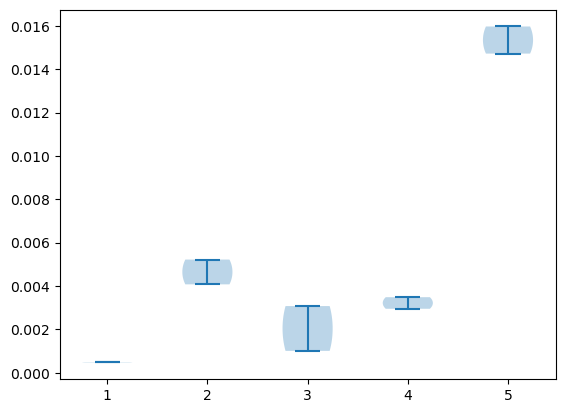

0.2 0.5820854 0.5797903 0.52387686
2 2


start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
101,0.2,0.4,0.0004,0.004,0.001,0.004,0.01,0.082708,0.0004923,0.0052209,0.0010103,0.0029514,0.0159668,0.5820854
107,0.2,0.4,0.0004,0.004,0.004,0.004,0.01,0.367263,0.0004755,0.0040768,0.0030759,0.0034858,0.0147164,0.5797903


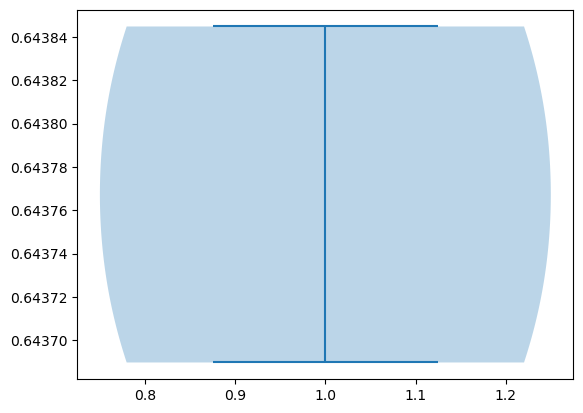

0.0003682 0.0003796 0.00037390000000000004
0.002293 0.0033449 0.0028189499999999998
0.0007661 0.0010112 0.00088865
0.0026057 0.0051112 0.00385845
0.0158399 0.0170094 0.01642465


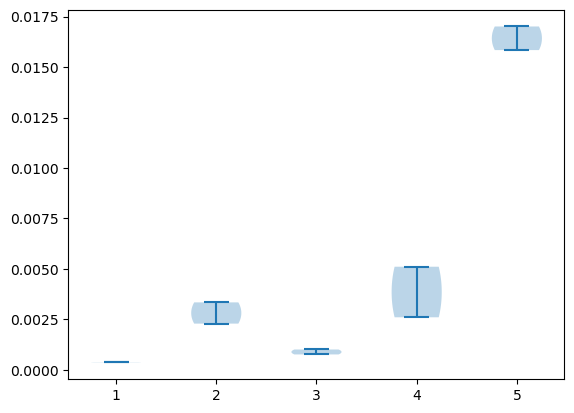

0.4 0.6438448 0.6436897 0.57946032
2 2


start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
101,0.4,0.6,0.0004,0.004,0.001,0.004,0.01,0.396751,0.0003682,0.0033449,0.0007661,0.0026057,0.0170094,0.6438448
107,0.4,0.6,0.0004,0.004,0.004,0.004,0.01,0.588812,0.0003796,0.002293,0.0010112,0.0051112,0.0158399,0.6436897


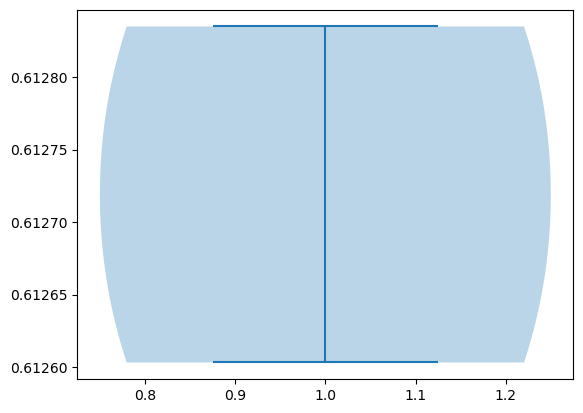

0.0003445 0.0003472 0.00034585
0.0010037 0.0010086 0.00100615
0.0008206 0.0011469 0.00098375
0.0054938 0.0062429 0.00586835
0.0149735 0.0151559 0.0150647


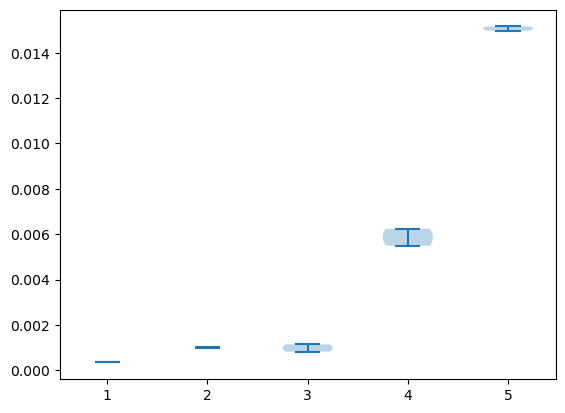

0.6 0.6128349 0.6126032 0.55155141
2 2


start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
107,0.6,0.8,0.0004,0.004,0.004,0.004,0.01,0.598182,0.0003472,0.0010037,0.0011469,0.0054938,0.0151559,0.6128349
101,0.6,0.8,0.0004,0.004,0.001,0.004,0.01,0.473958,0.0003445,0.0010086,0.0008206,0.0062429,0.0149735,0.6126032


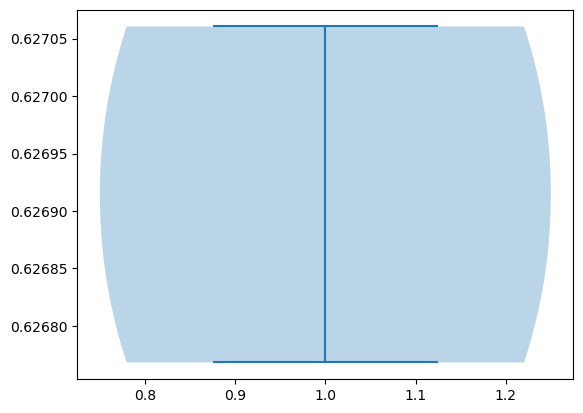

0.0001923 0.0002254 0.00020885
0.0010754 0.0029385 0.00200695
0.0014156 0.0018612 0.0016384
0.0023728 0.0033977 0.00288525
0.0152694 0.0153865 0.01532795


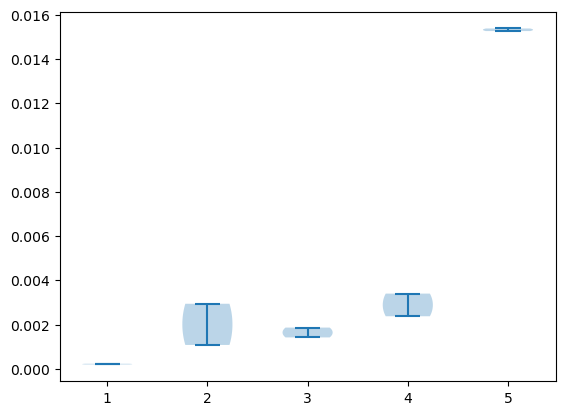

0.8 0.6270606 0.6267682 0.56435454
2 2


start_option,depriv_quantile_min,depriv_quantile_max,start_coeff_age_less65,start_coeff_age_65,start_coeff_age_70,start_coeff_age_75,start_coeff_age_over80,rsquared_without_opt,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
101,0.8,1.0,0.0004,0.004,0.001,0.004,0.01,0.578216,0.0001923,0.0029385,0.0014156,0.0023728,0.0152694,0.6270606
107,0.8,1.0,0.0004,0.004,0.004,0.004,0.01,0.583549,0.0002254,0.0010754,0.0018612,0.0033977,0.0153865,0.6267682


In [73]:
dict_results = {}

for q in quantile_min_list:
    print('\n')
    dict_results[q] = {}
    mask = df_admissions_lines_very_many['depriv_quantile_min'] == q
    df_here = df_admissions_lines_very_many.filter(mask).sort('rsquared', descending=True)
    r2_top = df_here['rsquared'].max()
    r2_bottom = df_here['rsquared'].min()

    plt.violinplot(df_here['rsquared'])
    plt.show()

    for col in cols_coeffs:
        print(df_here[col].min(), df_here[col].max(), df_here[col].median())
    plt.violinplot(df_here[cols_coeffs])
    plt.show()
    
    # Allow values within some tolerance of this max value:
    r2_low = r2_top * 0.90
    
    print(q, r2_top, r2_bottom, r2_low)
    

    df_q = pl.DataFrame()
    # mask_here = df_here['rsquared'] >= r2_low
    # df_h = df_here.filter(mask_here)
    df_h = df_here
    print(len(df_here), len(df_h))
    display(df_here)
    # for x in [10, 100, 1000, 10000]:
    # df_h = df_here[:x]
    means = df_h.mean()[cols_coeffs]
    stds = df_h.std()[cols_coeffs]

    # Add a column to mark how many fits went into these values.
    x = len(df_h)
    means = means.with_columns(pl.lit(x).alias('x'))
    # Rename std columns so later can combine stds and means
    # without repeating column names.
    stds = stds.rename(dict([(c, f'std_{c}') for c in stds.columns]))
    # Gather means and stds into one dataframe:
    means_stds = pl.concat((means, stds), how='horizontal')
    
    # Place this dataframe at the bottom of the existing dataframe:
    df_q = pl.concat((df_q, means_stds))

    dict_results[q] = df_q

Pick a value and see how many 

View results:

In [35]:
for q in quantile_min_list:
    print(q)
    display(dict_results[q])

0.0


coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,x,std_coeff_age_less65,std_coeff_age_65,std_coeff_age_70,std_coeff_age_75,std_coeff_age_over80
f64,f64,f64,f64,f64,i32,f64,f64,f64,f64,f64
0.000572,0.004984,0.004383,0.003051,0.015749,12,0.000031,0.002721,0.002467,0.002269,0.002498


0.2


coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,x,std_coeff_age_less65,std_coeff_age_65,std_coeff_age_70,std_coeff_age_75,std_coeff_age_over80
f64,f64,f64,f64,f64,i32,f64,f64,f64,f64,f64
0.000508,0.003072,0.00343,0.00269,0.015494,25,0.000036,0.002277,0.002427,0.002401,0.002404


0.4


coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,x,std_coeff_age_less65,std_coeff_age_65,std_coeff_age_70,std_coeff_age_75,std_coeff_age_over80
f64,f64,f64,f64,f64,i32,f64,f64,f64,f64,f64
0.000394,0.002018,0.001842,0.00261,0.016833,40,0.000069,0.001682,0.001637,0.001909,0.002097


0.6


coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,x,std_coeff_age_less65,std_coeff_age_65,std_coeff_age_70,std_coeff_age_75,std_coeff_age_over80
f64,f64,f64,f64,f64,i32,f64,f64,f64,f64,f64
0.000352,0.001351,0.002083,0.002662,0.015911,37,0.00006,0.00131,0.001745,0.002468,0.001949


0.8


coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,x,std_coeff_age_less65,std_coeff_age_65,std_coeff_age_70,std_coeff_age_75,std_coeff_age_over80
f64,f64,f64,f64,f64,i32,f64,f64,f64,f64,f64
0.000256,0.001914,0.001841,0.002609,0.01483,44,0.000085,0.001644,0.001583,0.002119,0.001957


In [36]:
print(stop, here, please)

NameError: name 'stop' is not defined

In [ ]:
dict_results_old = dict_results

In [ ]:
for q in quantile_min_list:
    print(q)
    display(dict_results[q])

## Fine grid results

In [2]:
df_coeffs_grid = pl.read_csv(os.path.join('outputs', 'line_fits_grid_ageonly_to_admissions_imd5_postopt.csv'))

In [3]:
df_coeffs_grid

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
i64,f64,f64,f64,f64,f64,f64,f64,f64
23040,0.8,1.0,0.0001,0.0007,0.0006,0.0007,0.012,-0.319585
23040,0.6,0.8,0.0001,0.0007,0.0006,0.0007,0.012,-0.727782
23040,0.4,0.6,0.0001,0.0007,0.0006,0.0007,0.012,-0.883591
23040,0.2,0.4,0.0001,0.0007,0.0006,0.0007,0.012,-1.567636
23040,0.0,0.2,0.0001,0.0007,0.0006,0.0007,0.012,-2.689707
…,…,…,…,…,…,…,…,…
103679,0.8,1.0,0.0007,0.009,0.006,0.009,0.019,-6.686296
103679,0.6,0.8,0.0007,0.009,0.006,0.009,0.019,-5.244426
103679,0.4,0.6,0.0007,0.009,0.006,0.009,0.019,-3.361456


In [4]:
mask = (
    (df_coeffs_grid['coeff_age_less65'] == 0.0003) &
    (df_coeffs_grid['coeff_age_65'] == 0.002) &
    (df_coeffs_grid['coeff_age_70'] == 0.003) &
    (df_coeffs_grid['coeff_age_75'] == 0.004) &
    (df_coeffs_grid['coeff_age_over80'] == 0.008)
)
df_coeffs_grid.filter(mask)

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
i64,f64,f64,f64,f64,f64,f64,f64,f64


In [4]:
len(df_coeffs_grid)

403200

In [5]:
quantile_min_list = df_coeffs_grid['depriv_quantile_min'].unique().to_numpy()

quantile_min_list

array([0. , 0.2, 0.4, 0.6, 0.8])

In [6]:
start_options = df_coeffs_grid['start_option'].unique()

Find how good R2 is compared with max available:

In [7]:
dict_quantile_max_r2 = {}

for q in quantile_min_list:
    df_here = df_coeffs_grid.filter(df_coeffs_grid['depriv_quantile_min'] == q)
    dict_quantile_max_r2[q] = df_here['rsquared'].max()

dict_quantile_max_r2

{0.0: 0.4999427005171354,
 0.2: 0.5847549383781983,
 0.4: 0.6454713431891492,
 0.6: 0.6151629147758857,
 0.8: 0.6282635223174148}

In [8]:
# Make columns for the results with a placeholder value:
df_coeffs_grid = df_coeffs_grid.with_columns(pl.lit(0).alias('rsquared_prop'))

for q in quantile_min_list:
    mask = df_coeffs_grid['depriv_quantile_min'] == q
    props = df_coeffs_grid['rsquared'] / dict_quantile_max_r2[q]
    
    df_coeffs_grid = df_coeffs_grid.with_columns(
        pl.when((mask))
        .then(props)         # replace with bin min
        .otherwise(pl.col('rsquared_prop'))  # otherwise keep the existing value
        .name.keep()
    )

In [9]:
df_coeffs_grid.sort('rsquared')

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
103679,0.8,1.0,0.0007,0.009,0.006,0.009,0.019,-6.686296,-10.642502
103671,0.8,1.0,0.0007,0.009,0.006,0.008,0.019,-6.263173,-9.969023
102719,0.8,1.0,0.0007,0.008,0.006,0.009,0.019,-6.160585,-9.805734
103583,0.8,1.0,0.0007,0.009,0.005,0.009,0.019,-6.113756,-9.731196
103678,0.8,1.0,0.0007,0.009,0.006,0.009,0.018,-6.077356,-9.673259
…,…,…,…,…,…,…,…,…,…
61604,0.4,0.6,0.0004,0.002,0.0007,0.006,0.016,0.645308,0.999747
61508,0.4,0.6,0.0004,0.002,0.0006,0.006,0.016,0.645334,0.999788
61877,0.4,0.6,0.0004,0.002,0.001,0.004,0.017,0.645439,0.99995


In [10]:
p = 0.995
dict_best_options = {}

for q in quantile_min_list:
    df_here = df_coeffs_grid.filter(df_coeffs_grid['depriv_quantile_min'] == q)

    # display(df_here.sort('rsquared', descending=True))

    df_here = df_here.filter(df_here['rsquared_prop'] >= p)

    dict_best_options[q] = df_here.sort('rsquared', descending=True)['start_option'][0]
    
    print(q)
    print(len(df_here))
    display(df_here.sort('rsquared', descending=True))
    display(df_here.sort('rsquared', descending=True).mean())
    display(df_here.sort('rsquared', descending=True).std())

0.0
142


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
88228,0.0,0.2,0.0006,0.005,0.006,0.0007,0.016,0.499943,1.0
89187,0.0,0.2,0.0006,0.006,0.006,0.0007,0.015,0.499911,0.999937
88236,0.0,0.2,0.0006,0.005,0.006,0.0008,0.016,0.499873,0.99986
89092,0.0,0.2,0.0006,0.006,0.005,0.0007,0.016,0.499778,0.99967
89195,0.0,0.2,0.0006,0.006,0.006,0.0008,0.015,0.499775,0.999665
…,…,…,…,…,…,…,…,…,…
89210,0.0,0.2,0.0006,0.006,0.006,0.001,0.014,0.497494,0.995103
87132,0.0,0.2,0.0006,0.004,0.004,0.005,0.016,0.497485,0.995085
91722,0.0,0.2,0.0006,0.009,0.002,0.003,0.014,0.497482,0.995078


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
89528.753521,0.0,0.2,0.000604,0.005965,0.004585,0.001806,0.01557,0.498411,0.996936


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2243.594906,0.0,0.0,0.00002,0.001591,0.001216,0.001368,0.001416,0.000686,0.001372


0.2
524


...

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
5133.200277,1.1115e-16,5.2397e-17,0.000047,0.000956,0.001025,0.0023,0.001299,0.000827,0.001344


0.8
558


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
40716,0.8,1.0,0.0002,0.004,0.001,0.0008,0.016,0.628264,1.0
40628,0.8,1.0,0.0002,0.004,0.0009,0.0009,0.016,0.62824,0.999962
40708,0.8,1.0,0.0002,0.004,0.001,0.0007,0.016,0.62823,0.999946
40819,0.8,1.0,0.0002,0.004,0.002,0.0009,0.015,0.628202,0.999902
40540,0.8,1.0,0.0002,0.004,0.0008,0.001,0.016,0.628197,0.999894
…,…,…,…,…,…,…,…,…,…
35187,0.8,1.0,0.0002,0.0007,0.003,0.004,0.015,0.625147,0.995039
40356,0.8,1.0,0.0002,0.004,0.0006,0.002,0.016,0.625135,0.99502
37986,0.8,1.0,0.0002,0.001,0.002,0.006,0.014,0.625127,0.995008


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
44575.374552,0.8,1.0,0.000254,0.002181,0.001975,0.002102,0.015159,0.626498,0.997189


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
5410.448314,9.0242e-17,0.0,0.00005,0.001471,0.00155,0.001647,0.001084,0.000814,0.001296


In [11]:
dict_best_options

{0.0: 88228, 0.2: 75580, 0.4: 62637, 0.6: 61011, 0.8: 40716}

Display just the best options:

In [12]:
mask = (False) * len(df_coeffs_grid)

for q, start_option in dict_best_options.items():
    mask += ((df_coeffs_grid['start_option'] == start_option) & (df_coeffs_grid['depriv_quantile_min'] == q)).to_numpy()

display(df_coeffs_grid.filter(mask.astype(bool)))

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
40716,0.8,1.0,0.0002,0.004,0.001,0.0008,0.016,0.628264,1.0
61011,0.6,0.8,0.0004,0.001,0.002,0.004,0.015,0.615163,1.0
62637,0.4,0.6,0.0004,0.003,0.0008,0.003,0.017,0.645471,1.0
75580,0.2,0.4,0.0005,0.004,0.004,0.001,0.016,0.584755,1.0
88228,0.0,0.2,0.0006,0.005,0.006,0.0007,0.016,0.499943,1.0


Are there any options where the probability increases nicely across age bands?

In [13]:
cols_coeffs = [c for c in df_coeffs_grid.columns if 'coeff' in c]

cols_coeffs

['coeff_age_less65',
 'coeff_age_65',
 'coeff_age_70',
 'coeff_age_75',
 'coeff_age_over80']

In [14]:
mask = (True) * len(df_coeffs_grid)

for c, col in enumerate(cols_coeffs[:-1]):
    print(col, cols_coeffs[c+1])
    mask *= (df_coeffs_grid[col] < df_coeffs_grid[cols_coeffs[c+1]]).to_numpy()

df_here = df_coeffs_grid.filter(mask.astype(bool))
# Also only keep good rsquared prop:
# df_here = df_here.filter(df_here['rsquared_prop'] > 0.995)

print(len(df_here))

coeff_age_less65 coeff_age_65
coeff_age_65 coeff_age_70
coeff_age_70 coeff_age_75
coeff_age_75 coeff_age_over80
51680


In [19]:
# Make columns for the results with a placeholder value:
df_here = df_here.with_columns(pl.lit(0).alias('rsquared_prop_minus'))

dict_props = {
    0.0: 0.989,
    0.2: 0.995,
    0.4: 0.996,
    0.6: 0.997,
    0.8: 0.995,
}

for q, prop_here in dict_props.items():
    mask = df_here['depriv_quantile_min'] == q
    df_here = df_here.with_columns(
        pl.when((mask))
        .then(df_here['rsquared_prop'] - prop_here)         # replace with bin min
        .otherwise(pl.col('rsquared_prop_minus'))  # otherwise keep the existing value
        .name.keep()
    )

df_here = df_here.filter(df_here['rsquared_prop_minus'] >= 0.0)

display(df_here)

for q in quantile_min_list:
    display(df_here.filter(df_here['depriv_quantile_min'] == q).sort('rsquared', descending=True))

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
35099,0.8,1.0,0.0002,0.0007,0.002,0.005,0.015,0.625549,0.99568,0.00068
35187,0.8,1.0,0.0002,0.0007,0.003,0.004,0.015,0.625147,0.995039,0.000039
35194,0.8,1.0,0.0002,0.0007,0.003,0.005,0.014,0.62542,0.995474,0.000474
36059,0.8,1.0,0.0002,0.0008,0.002,0.005,0.015,0.625478,0.995567,0.000567
36154,0.8,1.0,0.0002,0.0008,0.003,0.005,0.014,0.625464,0.995544,0.000544
…,…,…,…,…,…,…,…,…,…,…
97691,0.0,0.2,0.0007,0.003,0.004,0.005,0.015,0.495994,0.992102,0.003102
97698,0.0,0.2,0.0007,0.003,0.004,0.006,0.014,0.495116,0.990345,0.001345
97706,0.0,0.2,0.0007,0.003,0.004,0.007,0.014,0.494457,0.989028,0.000028


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
87234,0.0,0.2,0.0006,0.004,0.005,0.006,0.014,0.496646,0.993407,0.004407
86173,0.0,0.2,0.0006,0.003,0.004,0.005,0.017,0.496213,0.992539,0.003539
97691,0.0,0.2,0.0007,0.003,0.004,0.005,0.015,0.495994,0.992102,0.003102
87242,0.0,0.2,0.0006,0.004,0.005,0.007,0.014,0.495984,0.992081,0.003081
86275,0.0,0.2,0.0006,0.003,0.005,0.006,0.015,0.495769,0.991652,0.002652
…,…,…,…,…,…,…,…,…,…,…
94916,0.0,0.2,0.0007,0.0009,0.005,0.006,0.016,0.494546,0.989205,0.000205
96754,0.0,0.2,0.0007,0.002,0.004,0.008,0.014,0.494534,0.989182,0.000182
95890,0.0,0.2,0.0007,0.001,0.005,0.008,0.014,0.494528,0.989169,0.000169


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
74650,0.2,0.4,0.0005,0.003,0.004,0.005,0.014,0.58356,0.997957,0.002957
73691,0.2,0.4,0.0005,0.002,0.004,0.005,0.015,0.583316,0.99754,0.00254
81371,0.2,0.4,0.0006,0.0007,0.004,0.005,0.015,0.583185,0.997315,0.002315
82338,0.2,0.4,0.0006,0.0008,0.004,0.006,0.014,0.583103,0.997176,0.002176
83298,0.2,0.4,0.0006,0.0009,0.004,0.006,0.014,0.583083,0.997141,0.002141
…,…,…,…,…,…,…,…,…,…,…
83188,0.2,0.4,0.0006,0.0009,0.003,0.004,0.016,0.581883,0.995088,0.000088
81298,0.2,0.4,0.0006,0.0007,0.003,0.008,0.014,0.58188,0.995084,0.000084
83196,0.2,0.4,0.0006,0.0009,0.003,0.005,0.016,0.581875,0.995075,0.000075


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
61013,0.4,0.6,0.0004,0.001,0.002,0.004,0.017,0.645111,0.999442,0.003442
60053,0.4,0.6,0.0004,0.0009,0.002,0.004,0.017,0.644929,0.99916,0.00316
57957,0.4,0.6,0.0004,0.0007,0.0009,0.006,0.017,0.644813,0.99898,0.00298
59980,0.4,0.6,0.0004,0.0009,0.001,0.007,0.016,0.644777,0.998924,0.002924
58917,0.4,0.6,0.0004,0.0008,0.0009,0.006,0.017,0.644772,0.998916,0.002916
…,…,…,…,…,…,…,…,…,…,…
58939,0.4,0.6,0.0004,0.0008,0.0009,0.009,0.015,0.643104,0.996333,0.000333
58046,0.4,0.6,0.0004,0.0007,0.001,0.005,0.018,0.643054,0.996256,0.000256
58075,0.4,0.6,0.0004,0.0007,0.001,0.009,0.015,0.643011,0.996188,0.000188


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
61011,0.6,0.8,0.0004,0.001,0.002,0.004,0.015,0.615163,1.0,0.003
57955,0.6,0.8,0.0004,0.0007,0.0009,0.006,0.015,0.615141,0.999964,0.002964
58915,0.6,0.8,0.0004,0.0008,0.0009,0.006,0.015,0.615074,0.999855,0.002855
58051,0.6,0.8,0.0004,0.0007,0.001,0.006,0.015,0.615054,0.999823,0.002823
59084,0.6,0.8,0.0004,0.0008,0.002,0.003,0.016,0.615052,0.99982,0.00282
…,…,…,…,…,…,…,…,…,…,…
69548,0.6,0.8,0.0005,0.0007,0.001,0.003,0.016,0.613388,0.997115,0.000115
59113,0.6,0.8,0.0004,0.0008,0.002,0.007,0.013,0.613372,0.997089,0.000089
57881,0.6,0.8,0.0004,0.0007,0.0008,0.009,0.013,0.613348,0.99705,0.00005


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
49483,0.8,1.0,0.0003,0.001,0.002,0.003,0.015,0.628031,0.99963,0.00463
48523,0.8,1.0,0.0003,0.0009,0.002,0.003,0.015,0.628002,0.999583,0.004583
47563,0.8,1.0,0.0003,0.0008,0.002,0.003,0.015,0.627775,0.999222,0.004222
48428,0.8,1.0,0.0003,0.0009,0.001,0.003,0.016,0.627402,0.998628,0.003628
46603,0.8,1.0,0.0003,0.0007,0.002,0.003,0.015,0.62735,0.998545,0.003545
…,…,…,…,…,…,…,…,…,…,…
47673,0.8,1.0,0.0003,0.0008,0.003,0.005,0.013,0.625304,0.995289,0.000289
37019,0.8,1.0,0.0002,0.0009,0.002,0.005,0.015,0.625209,0.995139,0.000139
48443,0.8,1.0,0.0003,0.0009,0.001,0.005,0.015,0.625204,0.995131,0.000131


In [21]:
for q in quantile_min_list:
    df = df_here.filter(df_here['depriv_quantile_min'] == q).sort('rsquared', descending=True)
    print(q)
    display(df)
    df = df.drop(['start_option', 'depriv_quantile_min', 'depriv_quantile_max'])
    df = pl.concat((df[0], df.mean(), df.std(), df.min(), df.max()))
    display(df)
    print('\n'*5)

0.0


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
87234,0.0,0.2,0.0006,0.004,0.005,0.006,0.014,0.496646,0.993407,0.004407
86173,0.0,0.2,0.0006,0.003,0.004,0.005,0.017,0.496213,0.992539,0.003539
97691,0.0,0.2,0.0007,0.003,0.004,0.005,0.015,0.495994,0.992102,0.003102
87242,0.0,0.2,0.0006,0.004,0.005,0.007,0.014,0.495984,0.992081,0.003081
86275,0.0,0.2,0.0006,0.003,0.005,0.006,0.015,0.495769,0.991652,0.002652
…,…,…,…,…,…,…,…,…,…,…
94916,0.0,0.2,0.0007,0.0009,0.005,0.006,0.016,0.494546,0.989205,0.000205
96754,0.0,0.2,0.0007,0.002,0.004,0.008,0.014,0.494534,0.989182,0.000182
95890,0.0,0.2,0.0007,0.001,0.005,0.008,0.014,0.494528,0.989169,0.000169


coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,rsquared_prop_minus
f64,f64,f64,f64,f64,f64,f64,f64
0.0006,0.004,0.005,0.006,0.014,0.496646,0.993407,0.004407
0.000655,0.002479,0.005,0.006786,0.014357,0.495154,0.990421,0.001421
0.00005,0.001141,0.000733,0.000871,0.001226,0.000501,0.001002,0.001002
0.0006,0.0008,0.004,0.005,0.012,0.494457,0.989028,0.000028
0.0007,0.005,0.006,0.008,0.017,0.496646,0.993407,0.004407








0.2


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
74650,0.2,0.4,0.0005,0.003,0.004,0.005,0.014,0.58356,0.997957,0.002957
73691,0.2,0.4,0.0005,0.002,0.004,0.005,0.015,0.583316,0.99754,0.00254
81371,0.2,0.4,0.0006,0.0007,0.004,0.005,0.015,0.583185,0.997315,0.002315
82338,0.2,0.4,0.0006,0.0008,0.004,0.006,0.014,0.583103,0.997176,0.002176
83298,0.2,0.4,0.0006,0.0009,0.004,0.006,0.014,0.583083,0.997141,0.002141
…,…,…,…,…,…,…,…,…,…,…
83188,0.2,0.4,0.0006,0.0009,0.003,0.004,0.016,0.581883,0.995088,0.000088
81298,0.2,0.4,0.0006,0.0007,0.003,0.008,0.014,0.58188,0.995084,0.000084
83196,0.2,0.4,0.0006,0.0009,0.003,0.005,0.016,0.581875,0.995075,0.000075


...

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
61011,0.6,0.8,0.0004,0.001,0.002,0.004,0.015,0.615163,1.0,0.003
57955,0.6,0.8,0.0004,0.0007,0.0009,0.006,0.015,0.615141,0.999964,0.002964
58915,0.6,0.8,0.0004,0.0008,0.0009,0.006,0.015,0.615074,0.999855,0.002855
58051,0.6,0.8,0.0004,0.0007,0.001,0.006,0.015,0.615054,0.999823,0.002823
59084,0.6,0.8,0.0004,0.0008,0.002,0.003,0.016,0.615052,0.99982,0.00282
…,…,…,…,…,…,…,…,…,…,…
69548,0.6,0.8,0.0005,0.0007,0.001,0.003,0.016,0.613388,0.997115,0.000115
59113,0.6,0.8,0.0004,0.0008,0.002,0.007,0.013,0.613372,0.997089,0.000089
57881,0.6,0.8,0.0004,0.0007,0.0008,0.009,0.013,0.613348,0.99705,0.00005


coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,rsquared_prop_minus
f64,f64,f64,f64,f64,f64,f64,f64
0.0004,0.001,0.002,0.004,0.015,0.615163,1.0,0.003
0.000421,0.000792,0.001372,0.004774,0.015075,0.61411,0.998288,0.001288
0.000041,0.000096,0.000636,0.001565,0.001107,0.000585,0.00095,0.00095
0.0004,0.0007,0.0008,0.003,0.013,0.613329,0.99702,0.00002
0.0005,0.001,0.003,0.009,0.017,0.615163,1.0,0.003








0.8


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
49483,0.8,1.0,0.0003,0.001,0.002,0.003,0.015,0.628031,0.99963,0.00463
48523,0.8,1.0,0.0003,0.0009,0.002,0.003,0.015,0.628002,0.999583,0.004583
47563,0.8,1.0,0.0003,0.0008,0.002,0.003,0.015,0.627775,0.999222,0.004222
48428,0.8,1.0,0.0003,0.0009,0.001,0.003,0.016,0.627402,0.998628,0.003628
46603,0.8,1.0,0.0003,0.0007,0.002,0.003,0.015,0.62735,0.998545,0.003545
…,…,…,…,…,…,…,…,…,…,…
47673,0.8,1.0,0.0003,0.0008,0.003,0.005,0.013,0.625304,0.995289,0.000289
37019,0.8,1.0,0.0002,0.0009,0.002,0.005,0.015,0.625209,0.995139,0.000139
48443,0.8,1.0,0.0003,0.0009,0.001,0.005,0.015,0.625204,0.995131,0.000131


coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,rsquared_prop_minus
f64,f64,f64,f64,f64,f64,f64,f64
0.0003,0.001,0.002,0.003,0.015,0.628031,0.99963,0.00463
0.00028,0.000802,0.001573,0.004333,0.014843,0.626162,0.996654,0.001654
0.00004,0.000101,0.000729,0.001322,0.001155,0.000776,0.001236,0.001236
0.0002,0.0007,0.0008,0.002,0.013,0.625127,0.995008,0.000008
0.0003,0.001,0.003,0.006,0.017,0.628031,0.99963,0.00463


In [21]:
df_here['depriv_quantile_min'].unique()

depriv_quantile_min
f64
0.0
0.2
0.4
0.6
0.8


In [22]:
start_options_dict = {}

for q in quantile_min_list:
    start_options_dict[q] = df_here.filter(df_here['depriv_quantile_min'] == q)['start_option'].to_numpy()

start_options_dict

{0.0: array([85324, 85419, 86173, 86180, 86188, 86195, 86275, 86276, 86283,
        86290, 86378, 86385, 87234, 87235, 87242, 87249, 87337, 87344,
        88296, 93956, 93963, 94058, 94916, 94923, 95018, 95883, 95890,
        95978, 95985, 96732, 96739, 96747, 96754, 96834, 96842, 96849,
        96937, 97691, 97698, 97706, 97793, 98752]),
 0.2: array([71772, 72732, 73589, 73596, 73611, 73618, 73691, 73706, 74650,
        74665, 81188, 81276, 81283, 81298, 81371, 81378, 81473, 82148,
        82236, 82243, 82250, 82331, 82338, 82433, 83108, 83115, 83188,
        83196, 83203, 83210, 83291, 83298, 83305, 83393, 84068, 84075,
        84148, 84163, 84170, 84251, 84258, 84265, 84353, 85107, 85122,
        85129, 85217]),
 0.4: array([57854, 57861, 57868, 57876, 57883, 57935, 57950, 57957, 57964,
        57979, 58031, 58038, 58046, 58053, 58060, 58075, 58126, 58133,
        58141, 58148, 58155, 58228, 58236, 58243, 58895, 58902, 58910,
        58917, 58924, 58939, 58991, 58998, 59013, 59020, 

In [23]:
cols_coeffs

['coeff_age_less65',
 'coeff_age_65',
 'coeff_age_70',
 'coeff_age_75',
 'coeff_age_over80']

In [70]:
list_complete_sets = []


df_q0 = df_here.filter(df_here['depriv_quantile_min'] == quantile_min_list[0])
df_q1 = df_here.filter(df_here['depriv_quantile_min'] == quantile_min_list[1])
df_q2 = df_here.filter(df_here['depriv_quantile_min'] == quantile_min_list[2])
df_q3 = df_here.filter(df_here['depriv_quantile_min'] == quantile_min_list[3])
df_q4 = df_here.filter(df_here['depriv_quantile_min'] == quantile_min_list[4])

for h in range(len(df_q0)):
    # Pick out the coeffs for this start option:
    row0 = df_q0[h]
    # Compare with the higher q bands:
    mask_q1 = (
        (df_q1['coeff_age_less65'] <= row0['coeff_age_less65']) &
        (df_q1['coeff_age_65'] <= row0['coeff_age_65']) &
        (df_q1['coeff_age_70'] <= row0['coeff_age_70']) &
        (df_q1['coeff_age_75'] <= row0['coeff_age_75']) &
        (df_q1['coeff_age_over80'] <= row0['coeff_age_over80'])
    )
    df_q1_mask = df_q1.filter(mask_q1)
    for i in range(len(df_q1_mask)):
        row1 = df_q1_mask[i]
        # Are these coeffs higher or the same as the previous q band's coeffs?
        bool_01 = (row1[cols_coeffs] <= row0[cols_coeffs]).to_numpy()[0]
        # print('\n'*5, row0[cols_coeffs], row1[cols_coeffs], bool_01)
        if all(bool_01):
            # print(h, i)
            mask_q2 = (
                (df_q2['coeff_age_less65'] <= row1['coeff_age_less65']) &
                (df_q2['coeff_age_65'] <= row1['coeff_age_65']) &
                (df_q2['coeff_age_70'] <= row1['coeff_age_70']) &
                (df_q2['coeff_age_75'] <= row1['coeff_age_75']) &
                (df_q2['coeff_age_over80'] <= row1['coeff_age_over80'])
            )
            df_q2_mask = df_q2.filter(mask_q2)
            for j in range(len(df_q2_mask)):
                row2 = df_q2_mask[j]
                bool_12 = (row2[cols_coeffs] <= row1[cols_coeffs]).to_numpy()[0]
                if all(bool_12):
                    # print(h, i, j)
                    mask_q3 = (
                        (df_q3['coeff_age_less65'] <= row2['coeff_age_less65']) &
                        (df_q3['coeff_age_65'] <= row2['coeff_age_65']) &
                        (df_q3['coeff_age_70'] <= row2['coeff_age_70']) &
                        (df_q3['coeff_age_75'] <= row2['coeff_age_75']) &
                        (df_q3['coeff_age_over80'] <= row2['coeff_age_over80'])
                    )
                    df_q3_mask = df_q3.filter(mask_q3)
                    for k in range(len(df_q3_mask)):
                        row3 = df_q3_mask[k]
                        bool_23 = (row3[cols_coeffs] <= row2[cols_coeffs]).to_numpy()[0]
                        if all(bool_23):
                            # print(h, i, j, k)
                            mask_q4 = (
                                (df_q4['coeff_age_less65'] <= row3['coeff_age_less65']) &
                                (df_q4['coeff_age_65'] <= row3['coeff_age_65']) &
                                (df_q4['coeff_age_70'] <= row3['coeff_age_70']) &
                                (df_q4['coeff_age_75'] <= row3['coeff_age_75']) &
                                (df_q4['coeff_age_over80'] <= row3['coeff_age_over80'])
                            )
                            df_q4_mask = df_q4.filter(mask_q4)
                            for l in range(len(df_q4_mask)):
                                row4 = df_q4_mask[l]
                                bool_34 = (row4[cols_coeffs] <= row3[cols_coeffs]).to_numpy()[0]
                                if all(bool_34):
                                    # print(h, i, j, k, l)
                                    # df = pl.concat((row0, row1, row2, row3, row4))
                                    list_complete_sets.append([r['start_option'].to_numpy()[0] for r in [row0, row1, row2, row3, row4]])

In [71]:
list_complete_sets[0]

[85324, 71772, 58228, 58036, 46316]

In [72]:
len(list_complete_sets)

30586

In [79]:
np.savetxt(os.path.join('outputs', 'line_fits_options_ordered.csv'), np.array(list_complete_sets), fmt='%d', delimiter=',')

In [ ]:
df_complete_sets = pl.DataFrame(np.array(list_complete_sets).T, schema=['start_option_q00', 'start_option_q02','start_option_q04', 'start_option_q06', 'start_option_q08'])

### Calculate R2 combo of each set

In [26]:
df_complete_sets = pl.read_csv(os.path.join('outputs', 'line_fits_options_ordered.csv'), new_columns=['start_option_q00', 'start_option_q02','start_option_q04', 'start_option_q06', 'start_option_q08'])

In [27]:
df_complete_sets

start_option_q00,start_option_q02,start_option_q04,start_option_q06,start_option_q08
i64,i64,i64,i64,i64
85324,71772,58228,58036,46324
85324,71772,58228,58036,46412
85324,71772,58228,58036,46508
85324,71772,58228,58124,46316
85324,71772,58228,58124,46412
…,…,…,…,…
97691,85107,62067,61011,48530
97691,85107,62067,61011,49483
97691,85107,62067,61011,49490


In [28]:
df_complete_sets = df_complete_sets.with_columns((pl.int_range(pl.len())).alias('set_option'))

df_complete_sets

start_option_q00,start_option_q02,start_option_q04,start_option_q06,start_option_q08,set_option
i64,i64,i64,i64,i64,i64
85324,71772,58228,58036,46324,0
85324,71772,58228,58036,46412,1
85324,71772,58228,58036,46508,2
85324,71772,58228,58124,46316,3
85324,71772,58228,58124,46412,4
…,…,…,…,…,…
97691,85107,62067,61011,48530,30580
97691,85107,62067,61011,49483,30581
97691,85107,62067,61011,49490,30582


In [30]:
start_option_cols = [c for c in df_complete_sets.columns if 'start_option_q' in c]

dict_set_combo_r2 = {}

for set_option in df_complete_sets['set_option']:
    # Pick out data for these options:
    mask = np.array([False] * len(df_here))
    start_option_set = df_complete_sets.filter(df_complete_sets['set_option'] == set_option)[start_option_cols]
    for s, start_option in enumerate(start_option_set):
        mask += ((df_here['start_option'] == start_option) & (df_here['depriv_quantile_min'] == quantile_min_list[s])).to_numpy()
    df = df_here.filter(mask.astype(bool))

    # Calculate new combo R2:
    combo_r2 = df['rsquared'].sum()
    dict_set_combo_r2[set_option] = combo_r2

In [31]:
df_set_rsquared = pl.DataFrame({'set_option': dict_set_combo_r2.keys(), 'rsquared_combo_set': dict_set_combo_r2.values()})

df_set_rsquared

set_option,rsquared_combo_set
i64,f64
0,2.959457
1,2.960571
2,2.961116
3,2.961159
4,2.961941
…,…
30580,2.963391
30581,2.965718
30582,2.964112


In [32]:
df_complete_sets = df_complete_sets.join(df_set_rsquared, left_on='set_option', right_on='set_option', how='left')

In [33]:
df_complete_sets.sort('rsquared_combo_set', descending=True)

start_option_q00,start_option_q02,start_option_q04,start_option_q06,start_option_q08,set_option,rsquared_combo_set
i64,i64,i64,i64,i64,i64,f64
86173,73589,61013,61011,49483,6927,2.967132
86173,73589,61013,61011,48523,6925,2.967103
86173,73596,61108,61011,49483,7392,2.967088
86173,73596,61108,61011,48523,7390,2.967059
86173,73589,61013,61011,47563,6923,2.966876
…,…,…,…,…,…,…
94916,83108,60060,58908,46324,24513,2.958714
94916,83196,60060,58908,46324,24892,2.95852
94916,83196,58236,58036,46324,24820,2.95849


Merge in the coefficients:

In [34]:
set_option = df_complete_sets.sort('rsquared_combo_set', descending=True)['set_option'][0]

row_set = df_complete_sets.filter(df_complete_sets['set_option'] == set_option)

row0 = df_here.filter((df_here['start_option'] == row_set['start_option_q00']) & (df_here['depriv_quantile_min'] == quantile_min_list[0]))
row1 = df_here.filter((df_here['start_option'] == row_set['start_option_q02']) & (df_here['depriv_quantile_min'] == quantile_min_list[1]))
row2 = df_here.filter((df_here['start_option'] == row_set['start_option_q04']) & (df_here['depriv_quantile_min'] == quantile_min_list[2]))
row3 = df_here.filter((df_here['start_option'] == row_set['start_option_q06']) & (df_here['depriv_quantile_min'] == quantile_min_list[3]))
row4 = df_here.filter((df_here['start_option'] == row_set['start_option_q08']) & (df_here['depriv_quantile_min'] == quantile_min_list[4]))

df_best_set_combo_r2 = pl.concat((row0, row1, row2, row3, row4))

display(df_best_set_combo_r2)

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
86173,0.0,0.2,0.0006,0.003,0.004,0.005,0.017,0.496213,0.992539,0.003539
73589,0.2,0.4,0.0005,0.002,0.003,0.004,0.017,0.582614,0.996339,0.001339
61013,0.4,0.6,0.0004,0.001,0.002,0.004,0.017,0.645111,0.999442,0.003442
61011,0.6,0.8,0.0004,0.001,0.002,0.004,0.015,0.615163,1.0,0.003
49483,0.8,1.0,0.0003,0.001,0.002,0.003,0.015,0.628031,0.99963,0.00463


Find coeffs within two clicks either way of these best values:

In [35]:
df_best_set_combo_r2_max = df_best_set_combo_r2
df_best_set_combo_r2_min = df_best_set_combo_r2

df_best_set_combo_r2_max = df_best_set_combo_r2_max.with_columns(df_best_set_combo_r2_max['coeff_age_less65'] + 2e-4)
df_best_set_combo_r2_min = df_best_set_combo_r2_min.with_columns(df_best_set_combo_r2_min['coeff_age_less65'] - 2e-4)

df_best_set_combo_r2_max = df_best_set_combo_r2_max.with_columns(df_best_set_combo_r2_max['coeff_age_65'] + 2e-3)
df_best_set_combo_r2_min = df_best_set_combo_r2_min.with_columns(df_best_set_combo_r2_min['coeff_age_65'] - 2e-3)

df_best_set_combo_r2_max = df_best_set_combo_r2_max.with_columns(df_best_set_combo_r2_max['coeff_age_70'] + 2e-3)
df_best_set_combo_r2_min = df_best_set_combo_r2_min.with_columns(df_best_set_combo_r2_min['coeff_age_70'] - 2e-3)

df_best_set_combo_r2_max = df_best_set_combo_r2_max.with_columns(df_best_set_combo_r2_max['coeff_age_75'] + 2e-3)
df_best_set_combo_r2_min = df_best_set_combo_r2_min.with_columns(df_best_set_combo_r2_min['coeff_age_75'] - 2e-3)

df_best_set_combo_r2_max = df_best_set_combo_r2_max.with_columns(df_best_set_combo_r2_max['coeff_age_over80'] + 2e-3)
df_best_set_combo_r2_min = df_best_set_combo_r2_min.with_columns(df_best_set_combo_r2_min['coeff_age_over80'] - 2e-3)

# Manual overwrite:
dict_overwrite_min = {
    '0.001': 0.0008,
    '0.002': 0.0009,
}
for current_val, new_min in dict_overwrite_min.items():
    current_val = float(current_val)
    for col in cols_coeffs:
        mask = df_best_set_combo_r2[col] == current_val
        df_best_set_combo_r2_min = df_best_set_combo_r2_min.with_columns(
            pl.when((mask))
            .then(new_min)         # replace with bin min
            .otherwise(pl.col(col))  # otherwise keep the existing value
            .name.keep()
        )


for col in cols_coeffs:
    df_best_set_combo_r2_min = df_best_set_combo_r2_min.with_columns(df_best_set_combo_r2_min[col].round(4))
    df_best_set_combo_r2_max = df_best_set_combo_r2_max.with_columns(df_best_set_combo_r2_max[col].round(4))

In [36]:
df_best_set_combo_r2_max

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
86173,0.0,0.2,0.0008,0.005,0.006,0.007,0.019,0.496213,0.992539,0.003539
73589,0.2,0.4,0.0007,0.004,0.005,0.006,0.019,0.582614,0.996339,0.001339
61013,0.4,0.6,0.0006,0.003,0.004,0.006,0.019,0.645111,0.999442,0.003442
61011,0.6,0.8,0.0006,0.003,0.004,0.006,0.017,0.615163,1.0,0.003
49483,0.8,1.0,0.0005,0.003,0.004,0.005,0.017,0.628031,0.99963,0.00463


In [37]:
df_best_set_combo_r2_min

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
86173,0.0,0.2,0.0004,0.001,0.002,0.003,0.015,0.496213,0.992539,0.003539
73589,0.2,0.4,0.0003,0.0009,0.001,0.002,0.015,0.582614,0.996339,0.001339
61013,0.4,0.6,0.0002,0.0008,0.0009,0.002,0.015,0.645111,0.999442,0.003442
61011,0.6,0.8,0.0002,0.0008,0.0009,0.002,0.013,0.615163,1.0,0.003
49483,0.8,1.0,0.0001,0.0008,0.0009,0.001,0.013,0.628031,0.99963,0.00463


In [38]:
list_set_options_variation_of_best = []
list_set_options_not_variation_of_best = []

for set_option in df_complete_sets.sort('rsquared_combo_set', descending=True)['set_option']:
    row_set = df_complete_sets.filter(df_complete_sets['set_option'] == set_option)
    
    row0 = df_here.filter((df_here['start_option'] == row_set['start_option_q00']) & (df_here['depriv_quantile_min'] == quantile_min_list[0]))
    row1 = df_here.filter((df_here['start_option'] == row_set['start_option_q02']) & (df_here['depriv_quantile_min'] == quantile_min_list[1]))
    row2 = df_here.filter((df_here['start_option'] == row_set['start_option_q04']) & (df_here['depriv_quantile_min'] == quantile_min_list[2]))
    row3 = df_here.filter((df_here['start_option'] == row_set['start_option_q06']) & (df_here['depriv_quantile_min'] == quantile_min_list[3]))
    row4 = df_here.filter((df_here['start_option'] == row_set['start_option_q08']) & (df_here['depriv_quantile_min'] == quantile_min_list[4]))

    df = pl.concat((row0, row1, row2, row3, row4))

    for col in cols_coeffs:
        df = df.with_columns(df[col].round(4))

    # display(df)
    # display((df[cols_coeffs] >= df_best_set_combo_r2_min[cols_coeffs]))
    # display((df[cols_coeffs] >= df_best_set_combo_r2_min[cols_coeffs]).to_numpy().all())
    
    # display((df[cols_coeffs] <= df_best_set_combo_r2_max[cols_coeffs]))
    if ((df[cols_coeffs] >= df_best_set_combo_r2_min[cols_coeffs]).to_numpy().all() & (df[cols_coeffs] <= df_best_set_combo_r2_max[cols_coeffs]).to_numpy().all()):
        # display(df)
        list_set_options_variation_of_best.append(set_option)
    else:
        # display(df)
        # display((df[cols_coeffs] >= df_best_set_combo_r2_min[cols_coeffs]))
        # # display((df[cols_coeffs] >= df_best_set_combo_r2_min[cols_coeffs]).to_numpy().all())
        # display((df[cols_coeffs] <= df_best_set_combo_r2_max[cols_coeffs]))
        list_set_options_not_variation_of_best.append(set_option)

KeyboardInterrupt: 

In [ ]:
df_variation_of_best = pl.Series('set_option', list_set_options_variation_of_best).to_frame()
df_variation_of_best = df_variation_of_best.with_columns(pl.lit(True).alias('variation_of_best'))

df_complete_sets = df_complete_sets.join(df_variation_of_best, left_on='set_option', right_on='set_option', how='left')

In [ ]:
df_complete_sets.sort('rsquared_combo_set', descending=True)

In [ ]:
for i in [0.01, 0.10, 0.25, 0.50, 0.75, 1.00]:
    n_fits = int(round(i * len(df_complete_sets), 0))
    n_var = df_complete_sets.sort('rsquared_combo_set', descending=True)['variation_of_best_right'][:n_fits].sum()
    print(n_fits, n_var, round(n_var/n_fits, 2))

In [ ]:
df_complete_sets.write_csv(os.path.join('outputs', 'line_fits_options_ordered_with_r2.csv'))

In [39]:
df_complete_sets = pl.read_csv(os.path.join('outputs', 'line_fits_options_ordered_with_r2.csv'))

In [40]:
df_complete_sets

start_option_q00,start_option_q02,start_option_q04,start_option_q06,start_option_q08,set_option,rsquared_combo_set,variation_of_best
i64,i64,i64,i64,i64,i64,f64,bool
86173,73589,61013,61011,49483,6928,2.967132,true
86173,73589,61013,61011,48523,6926,2.967103,true
86173,73596,61108,61011,49483,7393,2.967088,true
86173,73596,61108,61011,48523,7391,2.967059,true
86173,73589,61013,61011,47563,6924,2.966876,true
…,…,…,…,…,…,…,…
94916,83108,60060,58908,46324,24514,2.958714,null
94916,83196,60060,58908,46324,24893,2.95852,null
94916,83196,58236,58036,46324,24821,2.95849,null


Pick out the first one that is not a variation of the best fit and check the coeffs:

In [41]:
set_option_here = df_complete_sets.filter(df_complete_sets['variation_of_best'].is_null())['set_option'][-1]

row_set = df_complete_sets.filter(df_complete_sets['set_option'] == set_option_here)

row0 = df_here.filter((df_here['start_option'] == row_set['start_option_q00']) & (df_here['depriv_quantile_min'] == quantile_min_list[0]))
row1 = df_here.filter((df_here['start_option'] == row_set['start_option_q02']) & (df_here['depriv_quantile_min'] == quantile_min_list[1]))
row2 = df_here.filter((df_here['start_option'] == row_set['start_option_q04']) & (df_here['depriv_quantile_min'] == quantile_min_list[2]))
row3 = df_here.filter((df_here['start_option'] == row_set['start_option_q06']) & (df_here['depriv_quantile_min'] == quantile_min_list[3]))
row4 = df_here.filter((df_here['start_option'] == row_set['start_option_q08']) & (df_here['depriv_quantile_min'] == quantile_min_list[4]))

df = pl.concat((row0, row1, row2, row3, row4))

for col in cols_coeffs:
    df = df.with_columns(df[col].round(4))

In [42]:
display(df)

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
94916,0.0,0.2,0.0007,0.0009,0.005,0.006,0.016,0.494546,0.989205,0.000205
71772,0.2,0.4,0.0005,0.0009,0.004,0.005,0.016,0.581833,0.995004,0.000004
58236,0.4,0.6,0.0004,0.0007,0.003,0.005,0.016,0.643124,0.996363,0.000363
58036,0.6,0.8,0.0004,0.0007,0.001,0.004,0.016,0.613626,0.997501,0.000501
46324,0.8,1.0,0.0003,0.0007,0.0008,0.004,0.016,0.62532,0.995314,0.000314


In [43]:
display(df_best_set_combo_r2)

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
86173,0.0,0.2,0.0006,0.003,0.004,0.005,0.017,0.496213,0.992539,0.003539
73589,0.2,0.4,0.0005,0.002,0.003,0.004,0.017,0.582614,0.996339,0.001339
61013,0.4,0.6,0.0004,0.001,0.002,0.004,0.017,0.645111,0.999442,0.003442
61011,0.6,0.8,0.0004,0.001,0.002,0.004,0.015,0.615163,1.0,0.003
49483,0.8,1.0,0.0003,0.001,0.002,0.003,0.015,0.628031,0.99963,0.00463


Set up dictionary of available coeff values and numbers of clicks from best option:

In [44]:
start_options_by_coeff = [
    np.arange(1e-4, 8e-4, 1e-4),
    np.concatenate((np.arange(7e-4, 1e-3, 1e-4), np.arange(1e-3, 1e-2, 1e-3))),
    np.concatenate((np.arange(6e-4, 9.9e-4, 1e-4), np.arange(1e-3, 7e-3, 1e-3))),
    np.concatenate((np.arange(7e-4, 1e-3, 1e-4), np.arange(1e-3, 1e-2, 1e-3))),
    np.arange(1.2e-2, 2.0e-2, 1e-3),
]
start_options_by_coeff = [np.round(s, 4) for s in start_options_by_coeff]

dict_start_options_by_coeff = dict(zip(cols_coeffs, start_options_by_coeff))

In [45]:
dict_start_options_by_coeff

{'coeff_age_less65': array([0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007]),
 'coeff_age_65': array([0.0007, 0.0008, 0.0009, 0.001 , 0.002 , 0.003 , 0.004 , 0.005 ,
        0.006 , 0.007 , 0.008 , 0.009 ]),
 'coeff_age_70': array([0.0006, 0.0007, 0.0008, 0.0009, 0.001 , 0.002 , 0.003 , 0.004 ,
        0.005 , 0.006 ]),
 'coeff_age_75': array([0.0007, 0.0008, 0.0009, 0.001 , 0.002 , 0.003 , 0.004 , 0.005 ,
        0.006 , 0.007 , 0.008 , 0.009 ]),
 'coeff_age_over80': array([0.012, 0.013, 0.014, 0.015, 0.016, 0.017, 0.018, 0.019])}

In [46]:
dict_coeff_counts = dict([(c, pl.DataFrame(dict_start_options_by_coeff[c], schema=[c])) for c in cols_coeffs])

for i, q in enumerate(quantile_min_list):
    df = df_here.filter(df_here['depriv_quantile_min'] == q).sort('rsquared', descending=True)
    # print(q)
    # display(df)
    for c, col in enumerate(cols_coeffs):
        # display(df[col].value_counts().sort(col))
        df_before = dict_coeff_counts[col]
        df_now = df[col].value_counts().rename({'count': f'count_q{q}'})
        # if i > 0:
        df_now = df_before.join(df_now, on=col, how='full', coalesce=True)
        # else:
        #     df_now = df_now
        dict_coeff_counts[col] = df_now
    
    # print('\n'*5)

for col, df in dict_coeff_counts.items():
    dict_coeff_counts[col] = df.sort(col)

In [47]:
for k, v in dict_coeff_counts.items():
    display(v)

coeff_age_less65,count_q0.0,count_q0.2,count_q0.4,count_q0.6,count_q0.8
f64,u32,u32,u32,u32,u32
0.0001,null,null,null,null,null
0.0002,null,null,null,null,10
0.0003,null,null,null,null,41
0.0004,null,null,62,42,null
0.0005,null,10,null,11,null
0.0006,19,37,null,null,null
0.0007,23,null,null,null,null


coeff_age_65,count_q0.0,count_q0.2,count_q0.4,count_q0.6,count_q0.8
f64,u32,u32,u32,u32,u32
0.0007,null,7,24,22,20
0.0008,3,7,17,17,15
0.0009,3,11,13,10,11
0.001,4,10,7,4,5
0.002,10,10,1,null,null
…,…,…,…,…,…
0.005,1,null,null,null,null
0.006,null,null,null,null,null
0.007,null,null,null,null,null


coeff_age_70,count_q0.0,count_q0.2,count_q0.4,count_q0.6,count_q0.8
f64,u32,u32,u32,u32,u32
0.0006,null,null,null,null,null
0.0007,null,null,null,null,null
0.0008,null,null,5,5,5
0.0009,null,null,11,13,8
0.001,null,null,17,16,13
0.002,null,6,19,16,19
0.003,null,20,10,3,6
0.004,11,17,null,null,null
0.005,20,4,null,null,null


coeff_age_75,count_q0.0,count_q0.2,count_q0.4,count_q0.6,count_q0.8
f64,u32,u32,u32,u32,u32
0.0007,null,null,null,null,null
0.0008,null,null,null,null,null
0.0009,null,null,null,null,null
0.001,null,null,null,null,null
0.002,null,null,null,null,5
…,…,…,…,…,…
0.005,3,12,10,4,17
0.006,12,18,13,11,11
0.007,18,11,10,8,null


coeff_age_over80,count_q0.0,count_q0.2,count_q0.4,count_q0.6,count_q0.8
f64,u32,u32,u32,u32,u32
0.012,3,null,null,null,null
0.013,7,9,null,4,6
0.014,13,12,null,13,15
0.015,11,13,15,16,16
0.016,7,12,18,15,9
0.017,1,1,12,5,5
0.018,null,null,12,null,null
0.019,null,null,5,null,null


Pick out which coeff is used in the "best" combo and say how many clicks away each other option is.

In [48]:
display(df_best_set_combo_r2)

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
86173,0.0,0.2,0.0006,0.003,0.004,0.005,0.017,0.496213,0.992539,0.003539
73589,0.2,0.4,0.0005,0.002,0.003,0.004,0.017,0.582614,0.996339,0.001339
61013,0.4,0.6,0.0004,0.001,0.002,0.004,0.017,0.645111,0.999442,0.003442
61011,0.6,0.8,0.0004,0.001,0.002,0.004,0.015,0.615163,1.0,0.003
49483,0.8,1.0,0.0003,0.001,0.002,0.003,0.015,0.628031,0.99963,0.00463


In [49]:
dict_start_options_by_coeff

{'coeff_age_less65': array([0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007]),
 'coeff_age_65': array([0.0007, 0.0008, 0.0009, 0.001 , 0.002 , 0.003 , 0.004 , 0.005 ,
        0.006 , 0.007 , 0.008 , 0.009 ]),
 'coeff_age_70': array([0.0006, 0.0007, 0.0008, 0.0009, 0.001 , 0.002 , 0.003 , 0.004 ,
        0.005 , 0.006 ]),
 'coeff_age_75': array([0.0007, 0.0008, 0.0009, 0.001 , 0.002 , 0.003 , 0.004 , 0.005 ,
        0.006 , 0.007 , 0.008 , 0.009 ]),
 'coeff_age_over80': array([0.012, 0.013, 0.014, 0.015, 0.016, 0.017, 0.018, 0.019])}

In [50]:
dict_clicks_away = {}

for q in quantile_min_list:
    dict_q = {}
    for col in cols_coeffs:
        c = df_best_set_combo_r2.filter(df_best_set_combo_r2['depriv_quantile_min'] == q)[col].to_numpy()[0]
        start_options_here = dict_start_options_by_coeff[col]
        i = np.where(round(c, 4) == np.round(start_options_here, 4))[0][0]
        dict_q[col] = dict(zip(start_options_here, np.abs(np.arange(len(start_options_here)) - i)))
    dict_clicks_away[q] = dict_q

In [51]:
dict_clicks_away

{0.0: {'coeff_age_less65': {0.0001: 5,
   0.0002: 4,
   0.0003: 3,
   0.0004: 2,
   0.0005: 1,
   0.0006: 0,
   0.0007: 1},
  'coeff_age_65': {0.0007: 5,
   0.0008: 4,
   0.0009: 3,
   0.001: 2,
   0.002: 1,
   0.003: 0,
   0.004: 1,
   0.005: 2,
   0.006: 3,
   0.007: 4,
   0.008: 5,
   0.009: 6},
  'coeff_age_70': {0.0006: 7,
   0.0007: 6,
   0.0008: 5,
   0.0009: 4,
   0.001: 3,
   0.002: 2,
   0.003: 1,
   0.004: 0,
   0.005: 1,
   0.006: 2},
  'coeff_age_75': {0.0007: 7,
   0.0008: 6,
   0.0009: 5,
   0.001: 4,
   0.002: 3,
   0.003: 2,
   0.004: 1,
   0.005: 0,
   0.006: 1,
   0.007: 2,
   0.008: 3,
   0.009: 4},
  'coeff_age_over80': {0.012: 5,
   0.013: 4,
   0.014: 3,
   0.015: 2,
   0.016: 1,
   0.017: 0,
   0.018: 1,
   0.019: 2}},
 0.2: {'coeff_age_less65': {0.0001: 4,
   0.0002: 3,
   0.0003: 2,
   0.0004: 1,
   0.0005: 0,
   0.0006: 1,
   0.0007: 2},
  'coeff_age_65': {0.0007: 4,
   0.0008: 3,
   0.0009: 2,
   0.001: 1,
   0.002: 0,
   0.003: 1,
   0.004: 2,
   0.005: 3,


In [52]:
df

coeff_age_over80,count_q0.0,count_q0.2,count_q0.4,count_q0.6,count_q0.8
f64,u32,u32,u32,u32,u32
0.012,3,null,null,null,null
0.013,7,9,null,4,6
0.014,13,12,null,13,15
0.015,11,13,15,16,16
0.016,7,12,18,15,9
0.017,1,1,12,5,5
0.018,null,null,12,null,null
0.019,null,null,5,null,null


In [53]:
dict_track_coeff_usage = dict((q, dict([(col, dict(zip(dict_start_options_by_coeff[col], [0]*len(start_options_here)))) for col in cols_coeffs])) for q in quantile_min_list)

dict_track_coeff_usage

{0.0: {'coeff_age_less65': {0.0001: 0,
   0.0002: 0,
   0.0003: 0,
   0.0004: 0,
   0.0005: 0,
   0.0006: 0,
   0.0007: 0},
  'coeff_age_65': {0.0007: 0,
   0.0008: 0,
   0.0009: 0,
   0.001: 0,
   0.002: 0,
   0.003: 0,
   0.004: 0,
   0.005: 0},
  'coeff_age_70': {0.0006: 0,
   0.0007: 0,
   0.0008: 0,
   0.0009: 0,
   0.001: 0,
   0.002: 0,
   0.003: 0,
   0.004: 0},
  'coeff_age_75': {0.0007: 0,
   0.0008: 0,
   0.0009: 0,
   0.001: 0,
   0.002: 0,
   0.003: 0,
   0.004: 0,
   0.005: 0},
  'coeff_age_over80': {0.012: 0,
   0.013: 0,
   0.014: 0,
   0.015: 0,
   0.016: 0,
   0.017: 0,
   0.018: 0,
   0.019: 0}},
 0.2: {'coeff_age_less65': {0.0001: 0,
   0.0002: 0,
   0.0003: 0,
   0.0004: 0,
   0.0005: 0,
   0.0006: 0,
   0.0007: 0},
  'coeff_age_65': {0.0007: 0,
   0.0008: 0,
   0.0009: 0,
   0.001: 0,
   0.002: 0,
   0.003: 0,
   0.004: 0,
   0.005: 0},
  'coeff_age_70': {0.0006: 0,
   0.0007: 0,
   0.0008: 0,
   0.0009: 0,
   0.001: 0,
   0.002: 0,
   0.003: 0,
   0.004: 0},
  'c

In [54]:
def map_clicks(df_mapped):
    for col in cols_coeffs:
        dict_new_col = {}
        for q in quantile_min_list:
            map_dict = dict_clicks_away[q][col]
            current_value = df_mapped.filter(df_mapped['depriv_quantile_min'] == q)[col].to_numpy()[0]
            dict_new_col[q] = map_dict[current_value]
        df_new_col = pl.DataFrame(np.array([list(dict_new_col.keys()), list(dict_new_col.values())]), schema=['depriv_quantile_min', f'clicks_{col}'])
        df_mapped = df_mapped.join(df_new_col, on='depriv_quantile_min', how='left')
    return df_mapped

In [55]:
import copy

In [56]:
track_points = np.round(np.array([0.01, 0.10, 0.25, 0.50, 0.75, 1.00]) * len(df_complete_sets), 0).astype(int)

track_points

array([  306,  3059,  7646, 15293, 22940, 30586])

In [111]:
# Dicts for tracking results:
# How many times is each coeff option used across all fits?
dict_track_coeff_usage = dict((q, dict([(col, dict(zip(dict_start_options_by_coeff[col], [0]*len(dict_start_options_by_coeff[col])))) for col in cols_coeffs])) for q in quantile_min_list)
# Store a copy of this at intervals:
dict_track_coeff_usage_by_top_n_fits = {}
# One per set number:
dict_n_coeffs_changed = {}
dict_total_clicks = {}
dict_mean_clicks = {}
dict_mean_clicks_of_those_changed = {}
# Clicks and coeffs together:
dict_clicks_coeffs_by_top_n_fits = {}
arr_clicks_coeffs = np.zeros((25, 50))
dict_clicks_coeffs_by_top_n_fits_mean_of_those_changed = {}
dict_clicks_coeffs_mean_of_those_changed = {}

for s, set_option_here in enumerate(df_complete_sets.sort('rsquared_combo_set', descending=True)['set_option']):
    

    row_set = df_complete_sets.filter(df_complete_sets['set_option'] == set_option_here)
    
    row0 = df_here.filter((df_here['start_option'] == row_set['start_option_q00']) & (df_here['depriv_quantile_min'] == quantile_min_list[0]))
    row1 = df_here.filter((df_here['start_option'] == row_set['start_option_q02']) & (df_here['depriv_quantile_min'] == quantile_min_list[1]))
    row2 = df_here.filter((df_here['start_option'] == row_set['start_option_q04']) & (df_here['depriv_quantile_min'] == quantile_min_list[2]))
    row3 = df_here.filter((df_here['start_option'] == row_set['start_option_q06']) & (df_here['depriv_quantile_min'] == quantile_min_list[3]))
    row4 = df_here.filter((df_here['start_option'] == row_set['start_option_q08']) & (df_here['depriv_quantile_min'] == quantile_min_list[4]))
    
    df = pl.concat((row0, row1, row2, row3, row4))
    
    for col in cols_coeffs:
        df = df.with_columns(df[col].round(4))

    for i in range(5):
        row = df[i]
        q = quantile_min_list[i]
        for col in cols_coeffs:
            v = row[col].to_numpy()[0]
            # ind = np.where(list(dict_track_coeff_usage[q][col].keys()) == row[col])[0][0]
            dict_track_coeff_usage[q][col][v] += 1

    if (s+1) in track_points:
        dict_track_coeff_usage_by_top_n_fits[s+1] = copy.deepcopy(dict_track_coeff_usage)
        
    
    df_mapped = map_clicks(df)
    
    click_cols = [c for c in df_mapped.columns if c.startswith('clicks')]
    total_clicks = int(df_mapped[click_cols].sum().sum_horizontal().to_numpy()[0])
    n_changed = int((df_mapped[click_cols] > 0).sum().sum_horizontal().to_numpy()[0])
    # Mean clicks out of all coeffs, not just the ones that changed:
    mean_clicks = total_clicks / int((df_mapped[click_cols] > -42).sum().sum_horizontal().to_numpy()[0])
    # Mean clicks out of coeffs that changed:
    mean_clicks_of_those_changed = total_clicks / n_changed if n_changed > 0 else 0

    dict_n_coeffs_changed[set_option_here] = n_changed
    dict_total_clicks[set_option_here] = total_clicks
    dict_mean_clicks[set_option_here] = mean_clicks
    dict_mean_clicks_of_those_changed[set_option_here] = mean_clicks_of_those_changed

    arr_clicks_coeffs[n_changed, total_clicks] += 1
    if (s+1) in track_points:
        dict_clicks_coeffs_by_top_n_fits[s+1] = copy.deepcopy(arr_clicks_coeffs)

    try:
        dict_here = dict_clicks_coeffs_mean_of_those_changed[n_changed]
    except KeyError:
        dict_clicks_coeffs_mean_of_those_changed[n_changed] = {}
        dict_here = dict_clicks_coeffs_mean_of_those_changed[n_changed]
    try:
        dict_here[mean_clicks_of_those_changed] += 1
    except KeyError:
        dict_here[mean_clicks_of_those_changed] = 1
    dict_clicks_coeffs_mean_of_those_changed[n_changed] = dict_here
    if (s+1) in track_points:
        dict_clicks_coeffs_by_top_n_fits_mean_of_those_changed[s+1] = copy.deepcopy(dict_clicks_coeffs_mean_of_those_changed)

In [58]:
dict_track_coeff_usage_by_top_n_fits

{306: {0.0: {'coeff_age_less65': {0.0001: 0,
    0.0002: 0,
    0.0003: 0,
    0.0004: 0,
    0.0005: 0,
    0.0006: 269,
    0.0007: 37},
   'coeff_age_65': {0.0007: 0,
    0.0008: 0,
    0.0009: 0,
    0.001: 0,
    0.002: 31,
    0.003: 273,
    0.004: 2,
    0.005: 0,
    0.006: 0,
    0.007: 0,
    0.008: 0,
    0.009: 0},
   'coeff_age_70': {0.0006: 0,
    0.0007: 0,
    0.0008: 0,
    0.0009: 0,
    0.001: 0,
    0.002: 0,
    0.003: 0,
    0.004: 285,
    0.005: 19,
    0.006: 2},
   'coeff_age_75': {0.0007: 0,
    0.0008: 0,
    0.0009: 0,
    0.001: 0,
    0.002: 0,
    0.003: 0,
    0.004: 0,
    0.005: 259,
    0.006: 22,
    0.007: 23,
    0.008: 2,
    0.009: 0},
   'coeff_age_over80': {0.012: 0,
    0.013: 0,
    0.014: 0,
    0.015: 26,
    0.016: 58,
    0.017: 222,
    0.018: 0,
    0.019: 0}},
  0.2: {'coeff_age_less65': {0.0001: 0,
    0.0002: 0,
    0.0003: 0,
    0.0004: 0,
    0.0005: 278,
    0.0006: 28,
    0.0007: 0},
   'coeff_age_65': {0.0007: 0,
    0.0008:

In [59]:
dict_track_coeff_usage

{0.0: {'coeff_age_less65': {0.0001: 0,
   0.0002: 0,
   0.0003: 0,
   0.0004: 0,
   0.0005: 0,
   0.0006: 23319,
   0.0007: 7267},
  'coeff_age_65': {0.0007: 0,
   0.0008: 470,
   0.0009: 1844,
   0.001: 1019,
   0.002: 9805,
   0.003: 16896,
   0.004: 552,
   0.005: 0,
   0.006: 0,
   0.007: 0,
   0.008: 0,
   0.009: 0},
  'coeff_age_70': {0.0006: 0,
   0.0007: 0,
   0.0008: 0,
   0.0009: 0,
   0.001: 0,
   0.002: 0,
   0.003: 0,
   0.004: 15292,
   0.005: 13665,
   0.006: 1629},
  'coeff_age_75': {0.0007: 0,
   0.0008: 0,
   0.0009: 0,
   0.001: 0,
   0.002: 0,
   0.003: 0,
   0.004: 0,
   0.005: 3883,
   0.006: 9919,
   0.007: 15155,
   0.008: 1629,
   0.009: 0},
  'coeff_age_over80': {0.012: 0,
   0.013: 0,
   0.014: 0,
   0.015: 9860,
   0.016: 18596,
   0.017: 2130,
   0.018: 0,
   0.019: 0}},
 0.2: {'coeff_age_less65': {0.0001: 0,
   0.0002: 0,
   0.0003: 0,
   0.0004: 0,
   0.0005: 10615,
   0.0006: 19971,
   0.0007: 0},
  'coeff_age_65': {0.0007: 880,
   0.0008: 2532,
   0.000

In [60]:
dict_n_coeffs_changed

{6928: 0,
 6926: 1,
 7393: 4,
 7391: 5,
 6924: 1,
 6903: 4,
 6908: 2,
 7389: 5,
 7367: 8,
 7372: 6,
 6870: 4,
 7004: 2,
 7002: 3,
 7345: 8,
 7489: 6,
 7487: 7,
 6755: 5,
 6760: 3,
 7215: 9,
 7220: 7,
 6901: 4,
 6906: 2,
 6722: 5,
 7365: 8,
 7370: 6,
 7193: 9,
 6921: 2,
 6920: 3,
 7000: 3,
 30534: 8,
 7386: 6,
 6978: 6,
 6983: 4,
 8045: 5,
 30532: 9,
 7385: 7,
 7485: 7,
 6922: 1,
 7317: 4,
 8043: 6,
 6753: 5,
 6758: 3,
 7213: 9,
 7480: 8,
 7218: 7,
 7315: 5,
 7387: 5,
 6956: 6,
 27605: 7,
 6525: 6,
 27603: 8,
 6867: 4,
 7441: 5,
 6523: 7,
 6810: 7,
 6815: 5,
 7439: 6,
 7342: 8,
 6835: 4,
 6869: 6,
 6918: 3,
 17369: 9,
 21723: 9,
 7087: 9,
 6976: 6,
 6902: 6,
 6981: 4,
 6788: 7,
 7326: 8,
 17367: 10,
 30530: 9,
 6636: 5,
 7344: 10,
 7383: 7,
 21721: 10,
 12311: 6,
 8041: 6,
 30525: 10,
 7366: 10,
 6898: 4,
 7478: 8,
 12309: 7,
 6904: 2,
 7313: 5,
 8019: 9,
 8024: 7,
 6997: 4,
 7292: 8,
 6873: 2,
 6719: 5,
 7297: 6,
 7362: 8,
 7368: 6,
 7190: 9,
 6900: 6,
 6996: 5,
 27601: 8,
 7348: 6,
 9

In [61]:
dict_total_clicks

{6928: 0,
 6926: 1,
 7393: 4,
 7391: 5,
 6924: 2,
 6903: 4,
 6908: 2,
 7389: 6,
 7367: 8,
 7372: 6,
 6870: 6,
 7004: 2,
 7002: 3,
 7345: 10,
 7489: 8,
 7487: 9,
 6755: 5,
 6760: 3,
 7215: 9,
 7220: 7,
 6901: 5,
 6906: 3,
 6722: 7,
 7365: 9,
 7370: 7,
 7193: 11,
 6921: 2,
 6920: 3,
 7000: 4,
 30534: 11,
 7386: 6,
 6978: 6,
 6983: 4,
 8045: 5,
 30532: 12,
 7385: 7,
 7485: 10,
 6922: 3,
 7317: 4,
 8043: 6,
 6753: 6,
 6758: 4,
 7213: 10,
 7480: 10,
 7218: 8,
 7315: 5,
 7387: 7,
 6956: 8,
 27605: 7,
 6525: 6,
 27603: 8,
 6867: 7,
 7441: 6,
 6523: 7,
 6810: 7,
 6815: 5,
 7439: 7,
 7342: 11,
 6835: 8,
 6869: 8,
 6918: 4,
 17369: 12,
 21723: 13,
 7087: 12,
 6976: 7,
 6902: 6,
 6981: 5,
 6788: 9,
 7326: 12,
 17367: 13,
 30530: 13,
 6636: 8,
 7344: 12,
 7383: 8,
 21721: 14,
 12311: 7,
 8041: 7,
 30525: 13,
 7366: 10,
 6898: 6,
 7478: 11,
 12309: 8,
 6904: 4,
 7313: 6,
 8019: 9,
 8024: 7,
 6997: 4,
 7292: 8,
 6873: 4,
 6719: 8,
 7297: 6,
 7362: 10,
 7368: 8,
 7190: 12,
 6900: 7,
 6996: 5,
 27601:

In [62]:
df_complete_sets

start_option_q00,start_option_q02,start_option_q04,start_option_q06,start_option_q08,set_option,rsquared_combo_set,variation_of_best
i64,i64,i64,i64,i64,i64,f64,bool
86173,73589,61013,61011,49483,6928,2.967132,true
86173,73589,61013,61011,48523,6926,2.967103,true
86173,73596,61108,61011,49483,7393,2.967088,true
86173,73596,61108,61011,48523,7391,2.967059,true
86173,73589,61013,61011,47563,6924,2.966876,true
…,…,…,…,…,…,…,…
94916,83108,60060,58908,46324,24514,2.958714,null
94916,83196,60060,58908,46324,24893,2.95852,null
94916,83196,58236,58036,46324,24821,2.95849,null


In [123]:
df_total_clicks = pl.DataFrame(np.array([list(dict_total_clicks.keys()), list(dict_total_clicks.values())]).T, schema=['set_option', 'total_clicks'])
df_mean_clicks = pl.DataFrame(np.array([list(dict_mean_clicks.keys()), list(dict_mean_clicks.values())]).T, schema=['set_option', 'mean_clicks'])
df_mean_clicks_changed = pl.DataFrame(np.array([list(dict_mean_clicks_of_those_changed.keys()), list(dict_mean_clicks_of_those_changed.values())]).T, schema=['set_option', 'mean_clicks_of_those_changed'])
df_n_coeffs_changed = pl.DataFrame(np.array([list(dict_n_coeffs_changed.keys()), list(dict_n_coeffs_changed.values())]).T, schema=['set_option', 'n_coeffs_changed'])

In [124]:
df_mean_clicks = df_mean_clicks.with_columns(pl.col('set_option').cast(int))
df_mean_clicks_changed = df_mean_clicks_changed.with_columns(pl.col('set_option').cast(int))

In [126]:
# df_complete_sets = df_complete_sets.join(df_total_clicks, on='set_option', how='left')
# df_complete_sets = df_complete_sets.join(df_mean_clicks, on='set_option', how='left')
df_complete_sets = df_complete_sets.join(df_mean_clicks_changed, on='set_option', how='left')
# df_complete_sets = df_complete_sets.join(df_n_coeffs_changed, on='set_option', how='left')

In [127]:
df_complete_sets.sort('total_clicks')

start_option_q00,start_option_q02,start_option_q04,start_option_q06,start_option_q08,set_option,rsquared_combo_set,variation_of_best,total_clicks,n_coeffs_changed,mean_clicks,mean_clicks_of_those_changed
i64,i64,i64,i64,i64,i64,f64,bool,i64,i64,f64,f64
86173,73589,61013,61011,49483,6928,2.967132,true,0,0,0.0,0.0
86173,73589,61013,61011,48523,6926,2.967103,true,1,1,0.04,1.0
86173,73589,61013,61011,47563,6924,2.966876,true,2,1,0.08,2.0
86173,73589,61013,60051,48523,6908,2.966845,true,2,2,0.08,1.0
86173,73589,61108,61011,49483,7004,2.966761,true,2,2,0.08,1.0
…,…,…,…,…,…,…,…,…,…,…,…
94923,83115,58155,58058,46338,25276,2.960707,null,44,21,1.76,2.095238
94923,83115,59115,57962,46338,25297,2.960366,null,44,21,1.76,2.095238
95883,83115,58155,57962,46338,25740,2.960031,null,44,21,1.76,2.095238


In [88]:
for t in sorted(list(set(dict_mean_clicks.values()))):
    print(t, len(np.where(np.array(list(dict_mean_clicks.values()) )== t)[0]))

0.0 1
0.04 1
0.08 5
0.12 7
0.16 16
0.2 21
0.24 41
0.28 61
0.32 102
0.36 160
0.4 239
0.44 354
0.48 483
0.52 631
0.56 779
0.6 928
0.64 1023
0.68 1149
0.72 1172
0.76 1230
0.8 1186
0.84 1226
0.88 1144
0.92 1148
0.96 1120
1.0 1148
1.04 1192
1.08 1236
1.12 1370
1.16 1391
1.2 1500
1.24 1437
1.28 1426
1.32 1258
1.36 1142
1.4 914
1.44 766
1.48 551
1.52 411
1.56 265
1.6 172
1.64 96
1.68 51
1.72 23
1.76 8
1.8 2


In [89]:
for t in range(min(dict_total_clicks.values()), max(dict_total_clicks.values())+1, 1):
    print(t, len(np.where(np.array(list(dict_total_clicks.values()) )== t)[0]))

0 1
1 1
2 5
3 7
4 16
5 21
6 41
7 61
8 102
9 160
10 239
11 354
12 483
13 631
14 779
15 928
16 1023
17 1149
18 1172
19 1230
20 1186
21 1226
22 1144
23 1148
24 1120
25 1148
26 1192
27 1236
28 1370
29 1391
30 1500
31 1437
32 1426
33 1258
34 1142
35 914
36 766
37 551
38 411
39 265
40 172
41 96
42 51
43 23
44 8
45 2


In [67]:
for t in range(min(dict_n_coeffs_changed.values()), max(dict_n_coeffs_changed.values())+1, 1):
    print(t, len(np.where(np.array(list(dict_n_coeffs_changed.values()) )== t)[0]))

0 1
1 3
2 9
3 20
4 24
5 55
6 88
7 220
8 327
9 608
10 779
11 1230
12 1710
13 2366
14 2781
15 3502
16 4391
17 4401
18 3813
19 2870
20 1240
21 148


### n clicks

In [68]:
n_clicks_min = df_complete_sets['total_clicks'].min()
n_clicks_max = df_complete_sets['total_clicks'].max()

dict_results_n_clicks = {}
for s in track_points:
    dict_results_n_clicks[str(s)] = {}
    df_s = df_complete_sets.sort('rsquared_combo_set', descending=True)[:s]
    for n in range(n_clicks_min, n_clicks_max+1):
        df_clicks = df_s.filter(df_s['total_clicks'] == n)
        dict_results_n_clicks[str(s)][str(n)] = len(df_clicks)

In [69]:
df_n_clicks_results = pl.from_dicts(list(dict_results_n_clicks.values())).transpose(include_header=True, header_name='n_clicks', column_names=[str(s) for s in track_points])

df_n_clicks_results

n_clicks,306,3059,7646,15293,22940,30586
str,i64,i64,i64,i64,i64,i64
"""0""",1,1,1,1,1,1
"""1""",1,1,1,1,1,1
"""2""",4,5,5,5,5,5
"""3""",5,7,7,7,7,7
"""4""",11,16,16,16,16,16
…,…,…,…,…,…,…
"""41""",0,0,8,25,63,96
"""42""",0,0,3,9,29,51
"""43""",0,0,1,3,12,23


In [70]:
for col in [c for c in df_n_clicks_results.columns if 'n' not in c]:
    print(df_n_clicks_results.filter(df_n_clicks_results[col] > 0)['n_clicks'].cast(int).max())

16
38
43
43
45
45


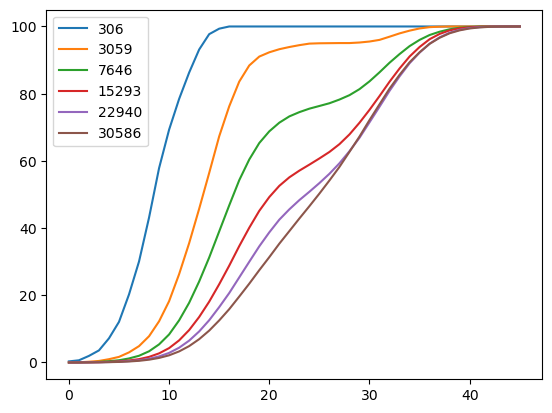

In [71]:
fig, ax = plt.subplots()

for col in [c for c in df_n_clicks_results.columns if 'n' not in c]:
    ax.plot(df_n_clicks_results['n_clicks'].cast(int), np.cumsum(100.0*(df_n_clicks_results[col] / df_n_clicks_results[col].sum())), label=col)

plt.legend()
plt.show()

### mean clicks

In [91]:
# mean_clicks_min = df_complete_sets['mean_clicks'].min()
# mean_clicks_max = df_complete_sets['mean_clicks'].max()

dict_results_mean_clicks = {}
for s in track_points:
    dict_results_mean_clicks[str(s)] = {}
    df_s = df_complete_sets.sort('rsquared_combo_set', descending=True)[:s]
    for n in sorted(list(set(dict_mean_clicks.values()))):
        df_clicks = df_s.filter(df_s['mean_clicks'] == n)
        dict_results_mean_clicks[str(s)][str(n)] = len(df_clicks)

In [92]:
df_mean_clicks_results = pl.from_dicts(list(dict_results_mean_clicks.values())).transpose(include_header=True, header_name='mean_clicks', column_names=[str(s) for s in track_points])

df_mean_clicks_results

mean_clicks,306,3059,7646,15293,22940,30586
str,i64,i64,i64,i64,i64,i64
"""0.0""",1,1,1,1,1,1
"""0.04""",1,1,1,1,1,1
"""0.08""",4,5,5,5,5,5
"""0.12""",5,7,7,7,7,7
"""0.16""",11,16,16,16,16,16
…,…,…,…,…,…,…
"""1.64""",0,0,8,25,63,96
"""1.68""",0,0,3,9,29,51
"""1.72""",0,0,1,3,12,23


In [100]:
with pl.Config(tbl_rows=50):

    display(df_mean_clicks_results)

mean_clicks,306,3059,7646,15293,22940,30586
str,i64,i64,i64,i64,i64,i64
"""0.0""",1,1,1,1,1,1
"""0.04""",1,1,1,1,1,1
"""0.08""",4,5,5,5,5,5
"""0.12""",5,7,7,7,7,7
"""0.16""",11,16,16,16,16,16
"""0.2""",15,21,21,21,21,21
"""0.24""",25,41,41,41,41,41
"""0.28""",30,57,61,61,61,61
"""0.32""",40,90,102,102,102,102


In [94]:
for col in [c for c in df_mean_clicks_results.columns if 'n' not in c]:
    print(df_mean_clicks_results.filter(df_mean_clicks_results[col] > 0)['mean_clicks'].cast(float).max())

0.64
1.52
1.72
1.72
1.8
1.8


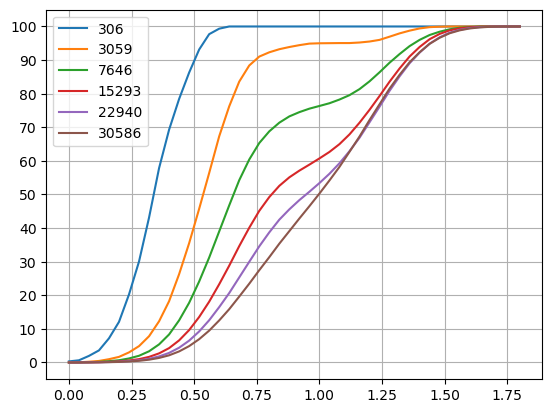

In [97]:
fig, ax = plt.subplots()

for col in [c for c in df_mean_clicks_results.columns if 'n' not in c]:
    ax.plot(df_mean_clicks_results['mean_clicks'].cast(float), np.cumsum(100.0*(df_mean_clicks_results[col] / df_mean_clicks_results[col].sum())), label=col)

ax.set_yticks(np.arange(0, 101, 10))
ax.grid()

plt.legend()
plt.show()

### mean clicks of those changed

In [136]:
# mean_clicks_min = df_complete_sets['mean_clicks'].min()
# mean_clicks_max = df_complete_sets['mean_clicks'].max()

dict_results_mean_clicks_changed = {}
for s in track_points:
    dict_results_mean_clicks_changed[str(s)] = {}
    df_s = df_complete_sets.sort('rsquared_combo_set', descending=True)[:s]
    for n in sorted(list(set(dict_mean_clicks_of_those_changed.values()))):
        df_clicks = df_s.filter(df_s['mean_clicks_of_those_changed'] == n)
        dict_results_mean_clicks_changed[str(s)][str(n)] = len(df_clicks)

In [137]:
df_mean_clicks_of_changed_results = pl.from_dicts(list(dict_results_mean_clicks_changed.values())).transpose(include_header=True, header_name='mean_clicks_of_those_changed', column_names=[str(s) for s in track_points])

df_mean_clicks_of_changed_results

mean_clicks_of_those_changed,306,3059,7646,15293,22940,30586
str,i64,i64,i64,i64,i64,i64
"""0""",1,1,1,1,1,1
"""1.0""",84,340,481,584,620,623
"""1.0588235294117647""",0,0,2,8,10,13
"""1.0625""",0,9,22,46,62,72
"""1.0666666666666667""",0,17,40,66,85,98
…,…,…,…,…,…,…
"""2.5833333333333335""",0,0,1,1,1,1
"""2.6153846153846154""",0,0,1,1,1,1
"""2.625""",0,0,0,1,1,1


In [165]:
df_mean_clicks_of_changed_results.sum()

mean_clicks_of_those_changed,306,3059,7646,15293,22940,30586
str,i64,i64,i64,i64,i64,i64
null,306,3059,7646,15293,22940,30586


In [138]:
with pl.Config(tbl_rows=50):

    display(dict_results_mean_clicks_changed)

{'306': {'0': 1,
  '1.0': 84,
  '1.0588235294117647': 0,
  '1.0625': 0,
  '1.0666666666666667': 0,
  '1.0714285714285714': 0,
  '1.0769230769230769': 0,
  '1.0833333333333333': 1,
  '1.0909090909090908': 5,
  '1.1': 6,
  '1.1111111111111112': 7,
  '1.1176470588235294': 0,
  '1.125': 11,
  '1.1333333333333333': 0,
  '1.1428571428571428': 10,
  '1.1538461538461537': 0,
  '1.1666666666666667': 9,
  '1.1764705882352942': 0,
  '1.1818181818181819': 6,
  '1.1875': 0,
  '1.2': 16,
  '1.2105263157894737': 0,
  '1.2142857142857142': 0,
  '1.2222222222222223': 6,
  '1.2307692307692308': 0,
  '1.2352941176470589': 0,
  '1.25': 11,
  '1.263157894736842': 0,
  '1.2666666666666666': 0,
  '1.2727272727272727': 6,
  '1.2777777777777777': 0,
  '1.2857142857142858': 14,
  '1.2941176470588236': 0,
  '1.3': 8,
  '1.3076923076923077': 0,
  '1.3125': 0,
  '1.3157894736842106': 0,
  '1.3333333333333333': 25,
  '1.3529411764705883': 0,
  '1.3571428571428572': 0,
  '1.3636363636363635': 3,
  '1.368421052631579

In [139]:
for col in [c for c in df_mean_clicks_of_changed_results.columns if 'n' not in c]:
    print(df_mean_clicks_of_changed_results.filter(df_mean_clicks_of_changed_results[col] > 0)['mean_clicks_of_those_changed'].cast(float).max())

3.0
3.0
3.0
3.0
3.0
3.0


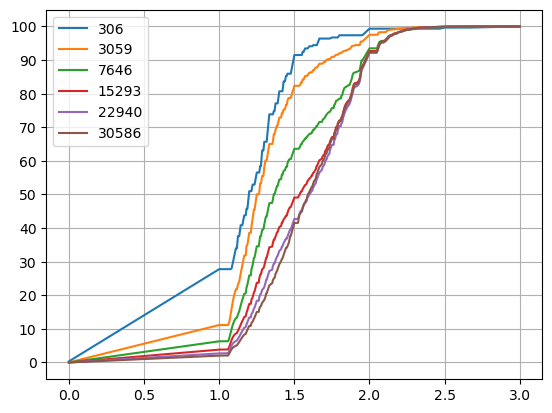

In [140]:
fig, ax = plt.subplots()

for col in [c for c in df_mean_clicks_of_changed_results.columns if 'n' not in c]:
    ax.plot(
        df_mean_clicks_of_changed_results['mean_clicks_of_those_changed'].cast(float),
        np.cumsum(100.0*(df_mean_clicks_of_changed_results[col] / df_mean_clicks_of_changed_results[col].sum())),
        label=col
    )

ax.set_yticks(np.arange(0, 101, 10))
ax.grid()

plt.legend()
plt.show()

### n changed

In [72]:
n_changed_min = df_complete_sets['n_coeffs_changed'].min()
n_changed_max = df_complete_sets['n_coeffs_changed'].max()

dict_results_n_changed = {}
for s in track_points:
    dict_results_n_changed[str(s)] = {}
    df_s = df_complete_sets.sort('rsquared_combo_set', descending=True)[:s]
    for n in range(n_changed_min, n_changed_max+1):
        df_changed = df_s.filter(df_s['total_clicks'] == n)
        dict_results_n_changed[str(s)][str(n)] = len(df_changed)

In [73]:
df_n_changed_results = pl.from_dicts(list(dict_results_n_changed.values())).transpose(include_header=True, header_name='n_changed', column_names=[str(s) for s in track_points])

df_n_changed_results

n_changed,306,3059,7646,15293,22940,30586
str,i64,i64,i64,i64,i64,i64
"""0""",1,1,1,1,1,1
"""1""",1,1,1,1,1,1
"""2""",4,5,5,5,5,5
"""3""",5,7,7,7,7,7
"""4""",11,16,16,16,16,16
…,…,…,…,…,…,…
"""17""",0,225,573,891,1068,1149
"""18""",0,147,471,836,1067,1172
"""19""",0,81,375,769,1055,1230


In [74]:
for col in [c for c in df_n_changed_results.columns if 'n' not in c]:
    print(df_n_changed_results.filter(df_n_changed_results[col] > 0)['n_changed'].cast(int).max())

16
21
21
21
21
21


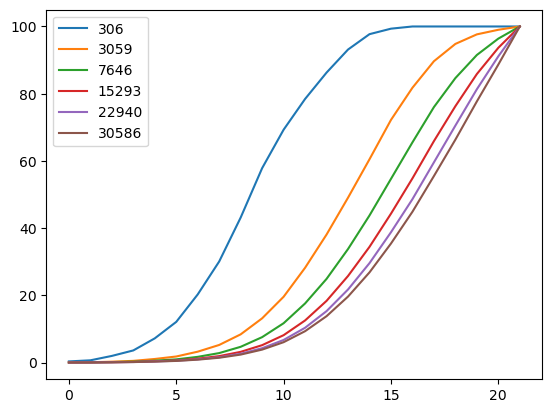

In [75]:
fig, ax = plt.subplots()

for col in [c for c in df_n_changed_results.columns if 'n' not in c]:
    ax.plot(df_n_changed_results['n_changed'].cast(int), np.cumsum(100.0*(df_n_changed_results[col] / df_n_changed_results[col].sum())), label=col)

plt.legend()
plt.show()

In [104]:
df_n_changed_results

n_changed,306,3059,7646,15293,22940,30586
str,i64,i64,i64,i64,i64,i64
"""0""",1,1,1,1,1,1
"""1""",1,1,1,1,1,1
"""2""",4,5,5,5,5,5
"""3""",5,7,7,7,7,7
"""4""",11,16,16,16,16,16
…,…,…,…,…,…,…
"""17""",0,225,573,891,1068,1149
"""18""",0,147,471,836,1067,1172
"""19""",0,81,375,769,1055,1230


## Grids

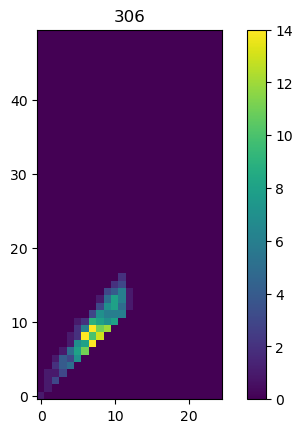

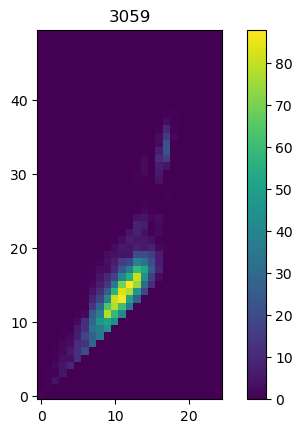

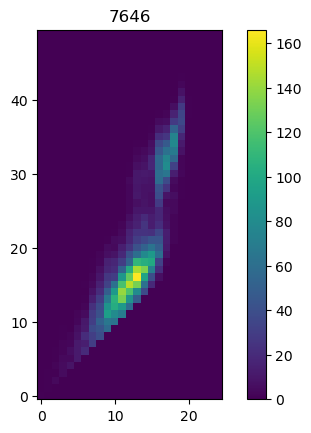

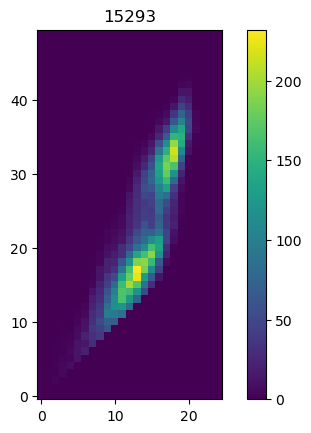

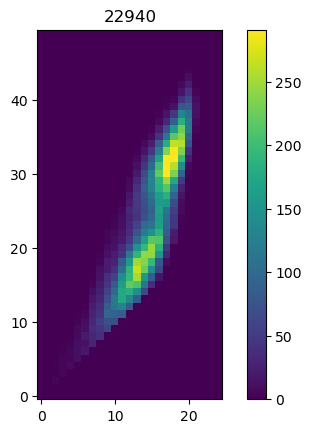

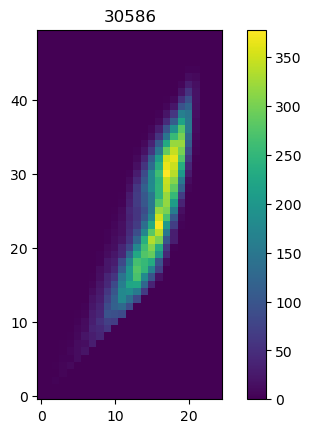

In [109]:
for key, arr in dict_clicks_coeffs_by_top_n_fits.items():
    plt.imshow(arr.T, origin='lower')
    plt.colorbar()
    plt.title(key)
    plt.show()

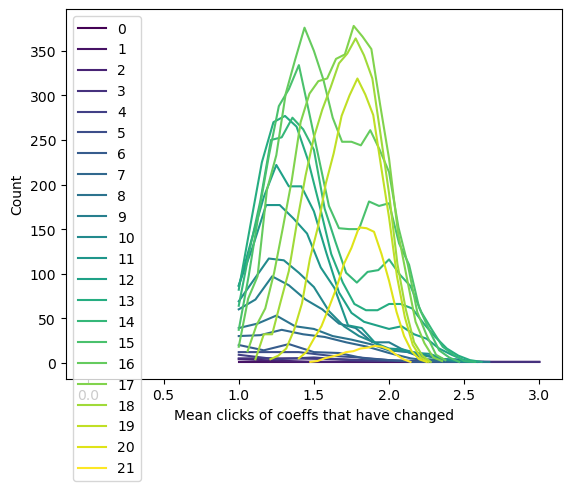

In [150]:
colours = plt.get_cmap('viridis')(np.linspace(0, 1, len(dict_clicks_coeffs_mean_of_those_changed)))

fig, ax = plt.subplots()

i = 0
for n_changed, dict_grid in dict(sorted(dict_clicks_coeffs_mean_of_those_changed.items())).items():
    # Convert dict to a grid:
    dict_grid = dict(sorted(dict_grid.items()))

    ax.plot(dict_grid.keys(), dict_grid.values(), label=n_changed, color=colours[i])
    i += 1


ax.legend()
ax.set_ylabel('Count')
ax.set_xlabel('Mean clicks of coeffs that have changed')
plt.show()

In [154]:
from statsmodels.stats.weightstats import DescrStatsW

In [155]:
dict_change_means = {}

for n_changed, dict_grid in dict(sorted(dict_clicks_coeffs_mean_of_those_changed.items())).items():
    m = DescrStatsW(list(dict_grid.keys()), weights=list(dict_grid.values()))
    dict_change_means[n_changed] = {}
    dict_change_means[n_changed]['mean_clicks_mean'] = m.mean
    dict_change_means[n_changed]['mean_clicks_std'] = m.std
    

In [161]:
df_change_means = pl.from_dicts(list(dict_change_means.values()))

df_change_means = df_change_means.with_columns(pl.Series('n_coeffs_changed', list(dict_change_means.keys())))

df_change_means = df_change_means.sort('n_coeffs_changed')

In [162]:
df_change_means

mean_clicks_mean,mean_clicks_std,n_coeffs_changed
f64,f64,i64
0.0,0.0,0
2.0,0.816497,1
1.666667,0.707107,2
1.633333,0.576387,3
1.34375,0.329239,4
…,…,…
1.678749,0.247698,17
1.701737,0.214624,18
1.75828,0.180301,19


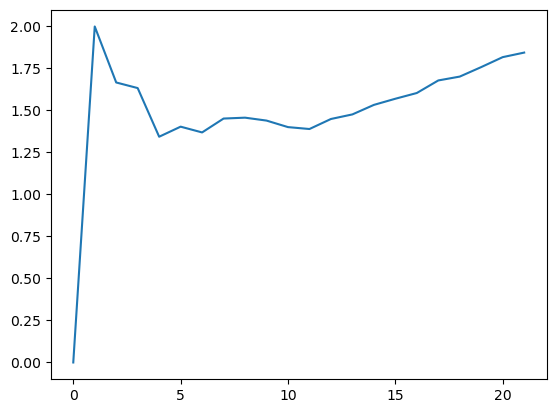

In [163]:
fig, ax = plt.subplots()

ax.plot(df_change_means['n_coeffs_changed'], df_change_means['mean_clicks_mean'])

plt.show()

## Fine grid results

In [5]:
df_coeffs_grid = pl.read_csv(os.path.join('outputs', 'line_fits_grid_ageonly_to_admissions_imd5_noopt_ssnap.csv'))

In [6]:
df_coeffs_grid

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
i64,f64,f64,f64,f64,f64,f64,f64,f64
0,0.8,1.0,0.00009,0.0009,0.001,0.002,0.006,-1.682585
0,0.6,0.8,0.00009,0.0009,0.001,0.002,0.006,-2.147451
0,0.4,0.6,0.00009,0.0009,0.001,0.002,0.006,-2.151906
0,0.2,0.4,0.00009,0.0009,0.001,0.002,0.006,-2.828133
0,0.0,0.2,0.00009,0.0009,0.001,0.002,0.006,-3.960894
…,…,…,…,…,…,…,…,…
10499,0.8,1.0,0.0004,0.004,0.005,0.006,0.01,0.430446
10499,0.6,0.8,0.0004,0.004,0.005,0.006,0.01,0.549458
10499,0.4,0.6,0.0004,0.004,0.005,0.006,0.01,0.627266


In [7]:
mask = (
    (df_coeffs_grid['coeff_age_less65'] == 0.0003) &
    (df_coeffs_grid['coeff_age_65'] == 0.002) &
    (df_coeffs_grid['coeff_age_70'] == 0.003) &
    (df_coeffs_grid['coeff_age_75'] == 0.004) &
    (df_coeffs_grid['coeff_age_over80'] == 0.008)
)
df_coeffs_grid.filter(mask)

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared
i64,f64,f64,f64,f64,f64,f64,f64,f64
7520,0.8,1.0,0.0003,0.002,0.003,0.004,0.008,0.338342
7520,0.6,0.8,0.0003,0.002,0.003,0.004,0.008,0.120881
7520,0.4,0.6,0.0003,0.002,0.003,0.004,0.008,0.002737
7520,0.2,0.4,0.0003,0.002,0.003,0.004,0.008,-0.448905
7520,0.0,0.2,0.0003,0.002,0.003,0.004,0.008,-1.233474
7529,0.8,1.0,0.0003,0.002,0.003,0.004,0.008,0.338342
7529,0.6,0.8,0.0003,0.002,0.003,0.004,0.008,0.120881
7529,0.4,0.6,0.0003,0.002,0.003,0.004,0.008,0.002737
7529,0.2,0.4,0.0003,0.002,0.003,0.004,0.008,-0.448905


In [8]:
len(df_coeffs_grid)

52500

In [9]:
quantile_min_list = df_coeffs_grid['depriv_quantile_min'].unique().to_numpy()

quantile_min_list

array([0. , 0.2, 0.4, 0.6, 0.8])

In [10]:
start_options = df_coeffs_grid['start_option'].unique()

Find how good R2 is compared with max available:

In [11]:
dict_quantile_max_r2 = {}

for q in quantile_min_list:
    df_here = df_coeffs_grid.filter(df_coeffs_grid['depriv_quantile_min'] == q)
    dict_quantile_max_r2[q] = df_here['rsquared'].max()

dict_quantile_max_r2

{0.0: 0.10297615007935612,
 0.2: 0.5067114586046856,
 0.4: 0.6272657039409992,
 0.6: 0.6017681447248877,
 0.8: 0.6152952042482875}

In [12]:
# Make columns for the results with a placeholder value:
df_coeffs_grid = df_coeffs_grid.with_columns(pl.lit(0).alias('rsquared_prop'))

for q in quantile_min_list:
    mask = df_coeffs_grid['depriv_quantile_min'] == q
    props = df_coeffs_grid['rsquared'] / dict_quantile_max_r2[q]
    
    df_coeffs_grid = df_coeffs_grid.with_columns(
        pl.when((mask))
        .then(props)         # replace with bin min
        .otherwise(pl.col('rsquared_prop'))  # otherwise keep the existing value
        .name.keep()
    )

In [13]:
df_coeffs_grid.sort('rsquared')

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
4,0.0,0.2,0.00009,0.0009,0.001,0.002,0.001,-5.560126,-53.994307
354,0.0,0.2,0.00009,0.001,0.001,0.002,0.001,-5.522218,-53.626188
704,0.0,0.2,0.00009,0.001,0.001,0.002,0.001,-5.522218,-53.626188
2104,0.0,0.2,0.0001,0.0009,0.001,0.002,0.001,-5.482528,-53.240754
2454,0.0,0.2,0.0001,0.001,0.001,0.002,0.001,-5.44486,-52.874962
…,…,…,…,…,…,…,…,…,…
10498,0.4,0.6,0.0004,0.004,0.005,0.006,0.009,0.619712,0.987957
10429,0.4,0.6,0.0004,0.004,0.004,0.006,0.01,0.625143,0.996616
10149,0.4,0.6,0.0004,0.003,0.005,0.006,0.01,0.625583,0.997317


In [14]:
p = 0.995
dict_best_options = {}

for q in quantile_min_list:
    df_here = df_coeffs_grid.filter(df_coeffs_grid['depriv_quantile_min'] == q)

    # display(df_here.sort('rsquared', descending=True))

    df_here = df_here.filter(df_here['rsquared_prop'] >= p)

    dict_best_options[q] = df_here.sort('rsquared', descending=True)['start_option'][0]
    
    print(q)
    print(len(df_here))
    display(df_here.sort('rsquared', descending=True))
    display(df_here.sort('rsquared', descending=True).mean())
    display(df_here.sort('rsquared', descending=True).std())

0.0
1


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
10499,0.0,0.2,0.0004,0.004,0.005,0.006,0.01,0.102976,1.0


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
10499.0,0.0,0.2,0.0004,0.004,0.005,0.006,0.01,0.102976,1.0


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
null,null,null,null,null,null,null,null,null,null


0.2
1


...

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
922.493722,0.0,1.1992e-16,0.000049,0.000816,0.000787,0.000787,0.0,0.001345,0.002235


0.8
15


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
6999,0.8,1.0,0.0003,0.001,0.005,0.006,0.01,0.615295,1.0
7349,0.8,1.0,0.0003,0.001,0.005,0.006,0.01,0.615295,1.0
6649,0.8,1.0,0.0003,0.0009,0.005,0.006,0.01,0.61511,0.999699
7629,0.8,1.0,0.0003,0.002,0.004,0.006,0.01,0.614985,0.999495
7685,0.8,1.0,0.0003,0.002,0.005,0.005,0.01,0.61438,0.998513
…,…,…,…,…,…,…,…,…,…
6215,0.8,1.0,0.0002,0.004,0.004,0.005,0.01,0.613056,0.996361
8189,0.8,1.0,0.0003,0.004,0.002,0.006,0.01,0.61299,0.996253
5599,0.8,1.0,0.0002,0.002,0.005,0.006,0.01,0.612719,0.995812


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
7289.266667,0.8,1.0,0.00028,0.00252,0.004267,0.0054,0.01,0.61379,0.997554


start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
951.771541,1.1492e-16,0.0,0.000056,0.001206,0.000961,0.000737,0.0,0.001069,0.001737


In [15]:
dict_best_options

{0.0: 10499, 0.2: 10499, 0.4: 10499, 0.6: 9799, 0.8: 6999}

Display just the best options:

In [16]:
mask = (False) * len(df_coeffs_grid)

for q, start_option in dict_best_options.items():
    mask += ((df_coeffs_grid['start_option'] == start_option) & (df_coeffs_grid['depriv_quantile_min'] == q)).to_numpy()

display(df_coeffs_grid.filter(mask.astype(bool)))

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
6999,0.8,1.0,0.0003,0.001,0.005,0.006,0.01,0.615295,1.0
9799,0.6,0.8,0.0004,0.002,0.005,0.006,0.01,0.601768,1.0
10499,0.4,0.6,0.0004,0.004,0.005,0.006,0.01,0.627266,1.0
10499,0.2,0.4,0.0004,0.004,0.005,0.006,0.01,0.506711,1.0
10499,0.0,0.2,0.0004,0.004,0.005,0.006,0.01,0.102976,1.0


In [12]:
mask = (False) * len(df_coeffs_grid)

for q, start_option in dict_best_options.items():
    mask += ((df_coeffs_grid['start_option'] == start_option) & (df_coeffs_grid['depriv_quantile_min'] == q)).to_numpy()

display(df_coeffs_grid.filter(mask.astype(bool)))

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
40716,0.8,1.0,0.0002,0.004,0.001,0.0008,0.016,0.628264,1.0
61011,0.6,0.8,0.0004,0.001,0.002,0.004,0.015,0.615163,1.0
62637,0.4,0.6,0.0004,0.003,0.0008,0.003,0.017,0.645471,1.0
75580,0.2,0.4,0.0005,0.004,0.004,0.001,0.016,0.584755,1.0
88228,0.0,0.2,0.0006,0.005,0.006,0.0007,0.016,0.499943,1.0
